# 데이터 확인하기 #
## 0. 라이브러리 임포트 & 경로 설정

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# 0. 라이브러리 임포트 & 경로 설정

import os
import json
import pandas as pd
from PIL import Image
import unicodedata  # 0번 섹션에 추가 필요
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import matplotlib
import matplotlib.pyplot as plt
from collections import Counter
import subprocess
import matplotlib as mpl
import numpy as np
import matplotlib.patches as patches
!pip install ultralytics -q
from ultralytics import YOLO
from ultralytics.utils import LOGGER
import logging
import shutil



In [21]:
# ── 디바이스 ──────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── 한글 폰트 ─────────────────────────────────────────────
result_apt = subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
if result_apt.returncode != 0:
    print("[경고] 폰트 설치 실패:", result_apt.stderr.decode())

result_fc = subprocess.run(['fc-cache', '-fv'], capture_output=True)
if result_fc.returncode != 0:
    print("[경고] 폰트 캐시 갱신 실패:", result_fc.stderr.decode())

mpl.font_manager.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# ── 경로 설정 ─────────────────────────────────────────────
def normalize_path(path):
    return unicodedata.normalize('NFC', path).strip()

extract_path        = normalize_path("/content/drive/MyDrive/data/초급_프로젝트/dataset/")

TRAIN_JSON_PATH     = normalize_path(os.path.join(extract_path, "merged_annotations_train_final.json"))
TEST_JSON_PATH      = normalize_path(os.path.join(extract_path, "merged_annotations_test_final.json"))
TRAIN_IMG_DIR       = normalize_path(os.path.join(extract_path, "train_images"))
TEST_IMG_DIR        = normalize_path(os.path.join(extract_path, "test_images"))
PROCESSED_IMG_DIR   = normalize_path(os.path.join(extract_path, "processed_images"))
PROCESSED_JSON_PATH = normalize_path(os.path.join(extract_path, "processed_train.json"))

os.makedirs(PROCESSED_IMG_DIR, exist_ok=True)

# ── 경로 존재 여부 검증 ────────────────────────────────────
paths_to_check = [
    ("TRAIN JSON    ", TRAIN_JSON_PATH),
    ("TEST  JSON    ", TEST_JSON_PATH),
    ("TRAIN IMG DIR ", TRAIN_IMG_DIR),
    ("TEST  IMG DIR ", TEST_IMG_DIR),
    ("PROCESSED IMG ", PROCESSED_IMG_DIR),
    ("PROCESSED JSON", PROCESSED_JSON_PATH),
]

print("경로 확인:")
for name, path in paths_to_check:
    status = "OK" if os.path.exists(path) else "없음"
    print(f"  {name} : {path}  [{status}]")

Device: cuda
경로 확인:
  TRAIN JSON     : /content/drive/MyDrive/data/초급_프로젝트/dataset/merged_annotations_train_final.json  [OK]
  TEST  JSON     : /content/drive/MyDrive/data/초급_프로젝트/dataset/merged_annotations_test_final.json  [OK]
  TRAIN IMG DIR  : /content/drive/MyDrive/data/초급_프로젝트/dataset/train_images  [OK]
  TEST  IMG DIR  : /content/drive/MyDrive/data/초급_프로젝트/dataset/test_images  [OK]
  PROCESSED IMG  : /content/drive/MyDrive/data/초급_프로젝트/dataset/processed_images  [OK]
  PROCESSED JSON : /content/drive/MyDrive/data/초급_프로젝트/dataset/processed_train.json  [OK]


## 1. 파일 존재 여부 및 기본 구조 확인

In [22]:
# 이미지 파일 개수 확인
IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp')

def count_images(directory):
    """디렉토리 내 이미지 파일 수를 반환"""
    if not os.path.exists(directory):
        return 0
    return sum(
        1 for entry in os.scandir(directory)
        if entry.is_file() and entry.name.lower().endswith(IMG_EXTENSIONS)
    )

EXPECTED = {"Train": 1489, "Test": 843}

n_train = count_images(TRAIN_IMG_DIR)
n_test  = count_images(TEST_IMG_DIR)

print(f"Train 이미지 수 : {n_train:,}  (기대값: {EXPECTED['Train']:,})")
print(f"Test  이미지 수 : {n_test:,}  (기대값: {EXPECTED['Test']:,})")
print(f"합계            : {n_train + n_test:,}")

if n_train != EXPECTED["Train"]:
    print(f"[경고] Train 이미지 수 불일치: {n_train} != {EXPECTED['Train']}")
if n_test != EXPECTED["Test"]:
    print(f"[경고] Test  이미지 수 불일치: {n_test} != {EXPECTED['Test']}")

Train 이미지 수 : 1,489  (기대값: 1,489)
Test  이미지 수 : 843  (기대값: 843)
합계            : 2,332


In [23]:
# 샘플 데이터 구조 확인
with open(TRAIN_JSON_PATH, 'r', encoding='utf-8') as f:
    train_json = json.load(f)

with open(TEST_JSON_PATH, 'r', encoding='utf-8') as f:
    test_json = json.load(f)

# ── 최상위 키 및 건수 ──────────────────────────────────────
for label, data in [("Train", train_json), ("Test", test_json)]:
    print(f"[{label}] 최상위 키: {list(data.keys())}")
    print(f"  images      : {len(data.get('images', [])):,}건")
    print(f"  annotations : {len(data.get('annotations', [])):,}건")
    print(f"  categories  : {len(data.get('categories', [])):,}건")
    print()

# ── 샘플 1건씩 출력 ───────────────────────────────────────
print("=== images[0] ===")
print(train_json['images'][0])

print("\n=== annotations[0] ===")
print(train_json['annotations'][0])

print("\n=== categories (앞 5개) ===")
for cat in train_json['categories'][:5]:
    print(cat)

# ── category_id 범위 및 연속성 확인 ──────────────────────
cat_ids = sorted(c['id'] for c in train_json['categories'])
expected_ids = list(range(min(cat_ids), max(cat_ids) + 1))
is_continuous = cat_ids == expected_ids

print(f"\ncategory_id 범위 : {min(cat_ids)} ~ {max(cat_ids)}")
print(f"연속성           : {'연속' if is_continuous else '[경고] 불연속 (재매핑 필요)'}")

[Train] 최상위 키: ['images', 'annotations', 'categories']
  images      : 1,489건
  annotations : 4,526건
  categories  : 73건

[Test] 최상위 키: ['images', 'annotations', 'categories']
  images      : 843건
  annotations : 1,129건
  categories  : 73건

=== images[0] ===
{'file_name': 'K-001900-016551-024850-027926_0_2_0_2_90_000_200.png', 'width': 976, 'height': 1280, 'imgfile': 'K-001900-016551-024850-027926_0_2_0_2_90_000_200.png', 'drug_N': 'K-001900', 'drug_S': '정상알약', 'back_color': '연회색 배경', 'drug_dir': '앞면', 'light_color': '주백색', 'camera_la': 90, 'camera_lo': 0, 'size': 200, 'dl_idx': '1899', 'dl_mapping_code': 'K-001900', 'dl_name': '보령부스파정 5mg', 'dl_name_en': 'Buspar Tab. 5mg Boryung', 'img_key': 'http://connectdi.com/design/img/drug/1Mxwka5v0lL.jpg', 'dl_material': '부스피론염산염', 'dl_material_en': 'Buspirone Hydrochloride', 'dl_custom_shape': '정제, 저작정', 'dl_company': '보령제약(주)', 'dl_company_en': 'Boryung', 'di_company_mf': '', 'di_company_mf_en': '', 'item_seq': 198700706, 'di_item_permit_date

## 3. 클래스 분포 분석

In [24]:
# category_id → 이름 매핑
id2name = {cat['id']: cat['name'] for cat in train_json['categories']}

# 클래스별 어노테이션 수 집계
cat_counter = Counter(annot['category_id'] for annot in train_json['annotations'])

df_class = pd.DataFrame([
    {'category_id': cid, 'name': id2name.get(cid, '?'), 'count': cnt}
    for cid, cnt in cat_counter.most_common()
])

print(f"총 클래스 수          : {len(df_class)}")
print(f"전체 어노테이션 수    : {df_class['count'].sum():,}")
print(f"평균 어노테이션 수    : {df_class['count'].mean():.1f}")
print(f"중앙값                : {df_class['count'].median():.1f}")
print(f"\n최다 클래스: {df_class.iloc[0]['name']} ({df_class.iloc[0]['count']}개)")
print(f"최소 클래스: {df_class.iloc[-1]['name']} ({df_class.iloc[-1]['count']}개)")
print(f"최대/최소 비율: {df_class['count'].max() / df_class['count'].min():.1f}x")

print(f"\n상위 10개 클래스:")
print(df_class.head(10).to_string(index=False))

print(f"\n하위 10개 클래스:")
print(df_class.tail(10).to_string(index=False))

총 클래스 수          : 73
전체 어노테이션 수    : 4,526
평균 어노테이션 수    : 62.0
중앙값                : 35.0

최다 클래스: 기넥신에프정(은행엽엑스)(수출용) (514개)
최소 클래스: 브린텔릭스정 20mg (7개)
최대/최소 비율: 73.4x

상위 10개 클래스:
 category_id               name  count
        3482 기넥신에프정(은행엽엑스)(수출용)    514
        3350        일양하이트린정 2mg    240
        1899         보령부스파정 5mg    180
        2482        뮤테란캡슐 100mg    172
       16547        가바토파정 100mg    143
       16550      동아가바펜틴정 800mg    139
       35205       아토젯정 10/40mg    113
       29666           리바로정 4mg    111
       16231          리피토정 20mg    109
       36636       로수젯정10/5밀리그램    108

하위 10개 클래스:
 category_id                     name  count
       18356  종근당글리아티린연질캡슐(콜린알포세레이트)      22
       33879           글리틴정(콜린알포세레이트)     21
       32309                글리아타민연질캡슐     18
       16687 오마코연질캡슐(오메가-3-산에틸에스테르90)     16
       12246              아빌리파이정 10mg     16
       27992              졸로푸트정 100mg     11
       23202               쿠에타핀정 25mg     10
       12419      

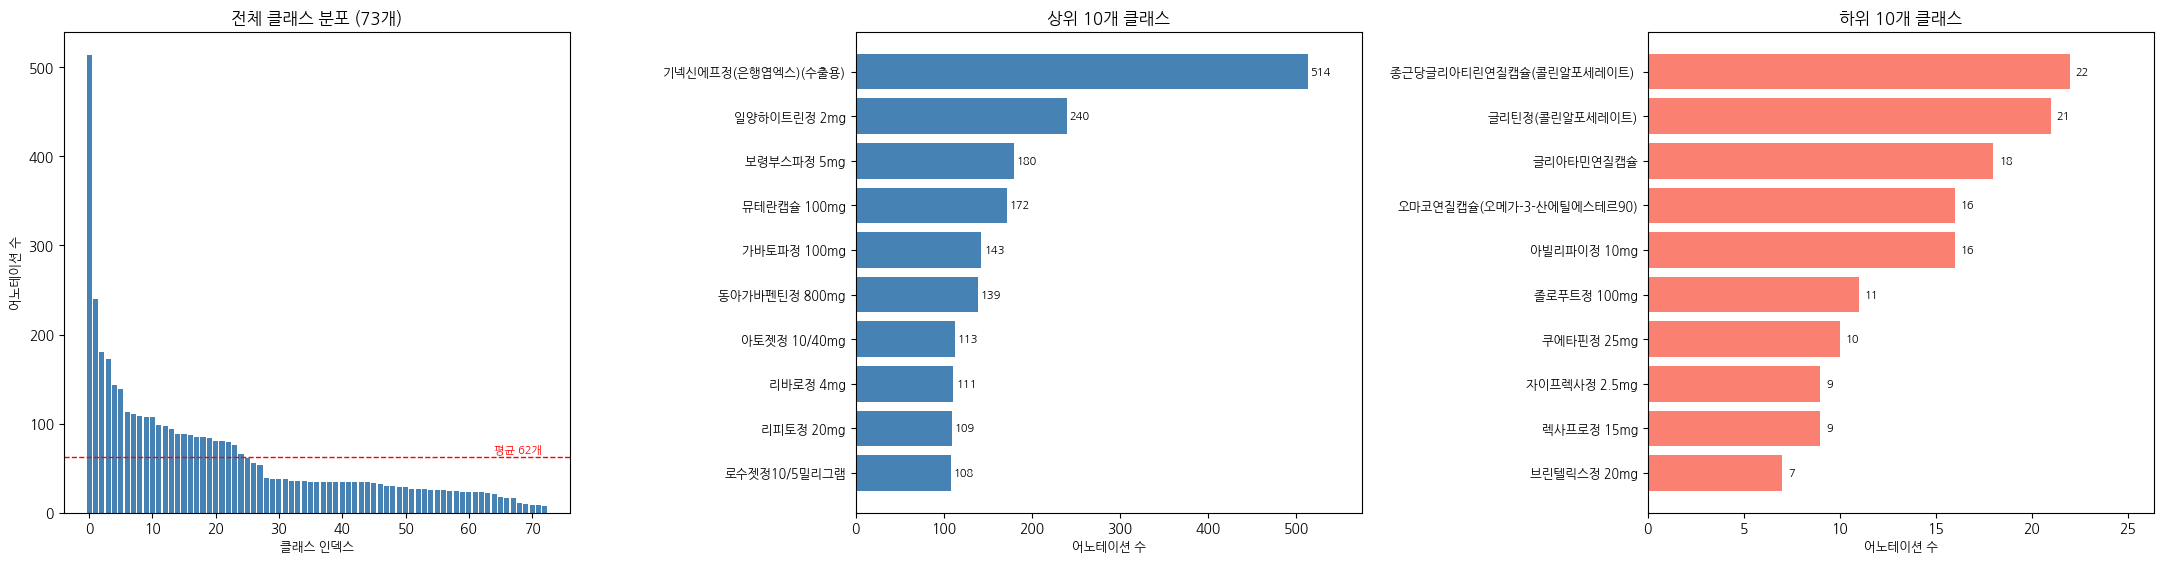

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# ── 전체 분포 ─────────────────────────────────────────────
axes[0].bar(range(len(df_class)), df_class['count'], color='steelblue', edgecolor='none')
mean_val = df_class['count'].mean()
axes[0].axhline(mean_val, color='red', linestyle='--', linewidth=1)
axes[0].text(len(df_class) * 0.98, mean_val + 5, f"평균 {mean_val:.0f}개",
             color='red', fontsize=8, ha='right')
axes[0].set_title('전체 클래스 분포 (73개)', fontsize=12)
axes[0].set_xlabel('클래스 인덱스', fontsize=9)
axes[0].set_ylabel('어노테이션 수', fontsize=9)

# ── 상위 10개 ─────────────────────────────────────────────
top10 = df_class.head(10).reset_index(drop=True)
bars = axes[1].barh(range(10), top10['count'], color='steelblue', edgecolor='none')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(top10['name'], fontsize=9)
axes[1].invert_yaxis()
axes[1].set_title('상위 10개 클래스', fontsize=12)
axes[1].set_xlabel('어노테이션 수', fontsize=9)
for i, v in enumerate(top10['count']):
    axes[1].text(v + 3, i, str(v), va='center', fontsize=8)
axes[1].set_xlim(0, top10['count'].max() * 1.12)

# ── 하위 10개 ─────────────────────────────────────────────
bot10 = df_class.tail(10).reset_index(drop=True)
axes[2].barh(range(10), bot10['count'], color='salmon', edgecolor='none')
axes[2].set_yticks(range(10))
axes[2].set_yticklabels(bot10['name'], fontsize=9)
axes[2].invert_yaxis()
axes[2].set_title('하위 10개 클래스', fontsize=12)
axes[2].set_xlabel('어노테이션 수', fontsize=9)
for i, v in enumerate(bot10['count']):
    axes[2].text(v + 0.3, i, str(v), va='center', fontsize=8)
axes[2].set_xlim(0, bot10['count'].max() * 1.2)

plt.tight_layout(pad=2.0)
plt.show()

## 4. EDA (데이터 정보 확인)

In [26]:
# ── 이미지 해상도 확인 ────────────────────────────────────
def check_resolution(data, label):
    widths  = [img['width']  for img in data['images']]
    heights = [img['height'] for img in data['images']]
    resolutions = Counter(zip(widths, heights))
    print(f"[{label}] 이미지 해상도 분포:")
    for (w, h), cnt in resolutions.most_common():
        print(f"  {w} x {h}: {cnt}장")

check_resolution(train_json, 'Train')
print()
check_resolution(test_json, 'Test')

[Train] 이미지 해상도 분포:
  976 x 1280: 1489장

[Test] 이미지 해상도 분포:
  976 x 1280: 843장


annotation 없는 이미지: 0장

이미지당 알약 수 분포:
  1개:   64장 (4.3%)
  2개:  302장 (20.3%)
  3개:  634장 (42.6%)
  4개:  489장 (32.8%)

평균: 3.04개 / 최대: 4개


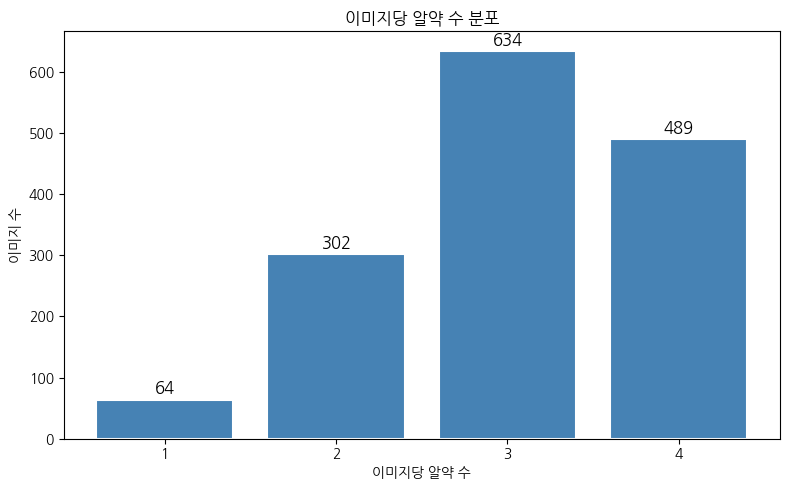

In [27]:
# ── 이미지당 알약 수 분포 ─────────────────────────────────
ann_per_image = Counter(ann['image_id'] for ann in train_json['annotations'])

# annotation 없는 이미지 확인
img_ids_all = {img['id'] for img in train_json['images']}
img_ids_with_ann = set(ann_per_image.keys())
no_ann_imgs = img_ids_all - img_ids_with_ann
print(f"annotation 없는 이미지: {len(no_ann_imgs)}장")

pill_dist = Counter(ann_per_image.values())
total_imgs = len(train_json['images'])

print("\n이미지당 알약 수 분포:")
for k in sorted(pill_dist.keys()):
    pct = pill_dist[k] / total_imgs * 100
    print(f"  {k}개: {pill_dist[k]:4d}장 ({pct:.1f}%)")

counts = list(ann_per_image.values())
print(f"\n평균: {np.mean(counts):.2f}개 / 최대: {np.max(counts)}개")

# 시각화
fig, ax = plt.subplots(figsize=(8, 5))
keys = sorted(pill_dist.keys())
vals = [pill_dist[k] for k in keys]
bars = ax.bar(keys, vals, color='steelblue', edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 5, str(v),
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_xlabel('이미지당 알약 수')
ax.set_ylabel('이미지 수')
ax.set_title('이미지당 알약 수 분포')
ax.set_xticks(keys)
plt.tight_layout()
plt.show()

이미지당 알약 수 분포

사용 이유: 모델이 한 이미지에서 최대 몇 개의 객체를 감지해야 하는지 파악하기 위함입니다.

얻은 것

- annotation 없는 이미지 0장 → 데이터 누락 없음
- 1개: 64장 / 2개: 302장 / 3개: 634장 / 4개: 489장
- 평균 3.04개, 최대 4개

알 수 있는 것

- 3~4개가 전체의 75.6%로 대부분입니다. 모델이 다중 객체 탐지에 최적화되어야 합니다.
- 1개짜리 이미지가 4.3%로 소수입니다. 단일 객체 이미지가 적어 단독 객체 학습이 상대적으로 부족할 수 있습니다.
- 최대 4개로 고정되어 있어 anchor 수, NMS threshold 설정 시 참고 기준이 됩니다.

비정상 BBox 수: 2개
  ann_id=903 / image_id=239 / bbox=[6567, 625, 311, 315] / 사유=x 범위 초과 (x+w=6878 > 976)
  ann_id=1157 / image_id=310 / bbox=[653, 8889, 217, 217] / 사유=y 범위 초과 (y+h=9106 > 1280)

BBox 크기 통계 (이미지 대비 비율):
  너비 비율 - 평균: 26.6%, 최소: 12.8%, 최대: 54.2%
  높이 비율 - 평균: 22.6%, 최소: 9.6%, 최대: 52.3%
  면적 비율 - 평균: 6.3%, 최대: 21.8%


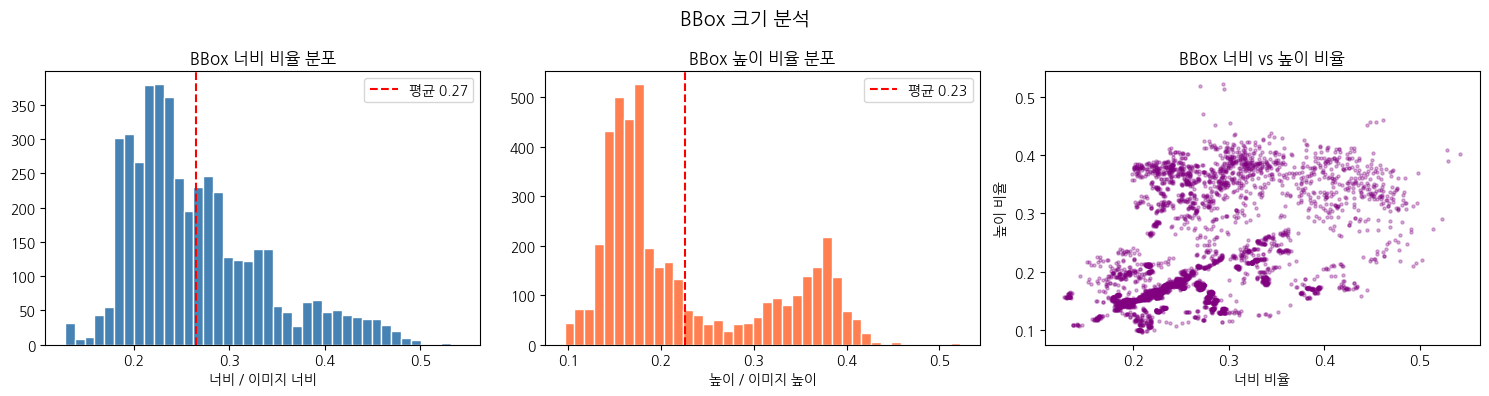

In [28]:
# ── BBox 크기 분석 ────────────────────────────────────────
img_id2info = {img['id']: img for img in train_json['images']}

bbox_w_ratios, bbox_h_ratios, bbox_areas = [], [], []
invalid_bboxes = []

for ann in train_json['annotations']:
    img = img_id2info[ann['image_id']]
    x, y, w, h = ann['bbox']
    iw, ih = img['width'], img['height']

    # 이상치 탐지
    reasons = []
    if x < 0 or y < 0:
        reasons.append(f"음수 좌표 (x={x}, y={y})")
    if w <= 0 or h <= 0:
        reasons.append(f"비정상 크기 (w={w}, h={h})")
    if x + w > iw:
        reasons.append(f"x 범위 초과 (x+w={x+w} > {iw})")
    if y + h > ih:
        reasons.append(f"y 범위 초과 (y+h={y+h} > {ih})")
    if reasons:
        invalid_bboxes.append({
            'ann_id'  : ann['id'],
            'image_id': ann['image_id'],
            'bbox'    : ann['bbox'],
            'reason'  : ' / '.join(reasons)
        })

    bbox_w_ratios.append(w / iw)
    bbox_h_ratios.append(h / ih)
    bbox_areas.append((w * h) / (iw * ih))

# ── 이상치 결과 출력 ──────────────────────────────────────
print(f"비정상 BBox 수: {len(invalid_bboxes)}개")
if invalid_bboxes:
    for item in invalid_bboxes:
        print(f"  ann_id={item['ann_id']} / image_id={item['image_id']} "
              f"/ bbox={item['bbox']} / 사유={item['reason']}")

# ── BBox 크기 통계 ────────────────────────────────────────
print("\nBBox 크기 통계 (이미지 대비 비율):")
print(f"  너비 비율 - 평균: {np.mean(bbox_w_ratios)*100:.1f}%, "
      f"최소: {np.min(bbox_w_ratios)*100:.1f}%, "
      f"최대: {np.max(bbox_w_ratios)*100:.1f}%")
print(f"  높이 비율 - 평균: {np.mean(bbox_h_ratios)*100:.1f}%, "
      f"최소: {np.min(bbox_h_ratios)*100:.1f}%, "
      f"최대: {np.max(bbox_h_ratios)*100:.1f}%")
print(f"  면적 비율 - 평균: {np.mean(bbox_areas)*100:.1f}%, "
      f"최대: {np.max(bbox_areas)*100:.1f}%")

# ── 시각화 ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(bbox_w_ratios, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('BBox 너비 비율 분포')
axes[0].set_xlabel('너비 / 이미지 너비')
axes[0].axvline(np.mean(bbox_w_ratios), color='red', linestyle='--',
                label=f'평균 {np.mean(bbox_w_ratios):.2f}')
axes[0].legend()

axes[1].hist(bbox_h_ratios, bins=40, color='coral', edgecolor='white')
axes[1].set_title('BBox 높이 비율 분포')
axes[1].set_xlabel('높이 / 이미지 높이')
axes[1].axvline(np.mean(bbox_h_ratios), color='red', linestyle='--',
                label=f'평균 {np.mean(bbox_h_ratios):.2f}')
axes[1].legend()

axes[2].scatter(bbox_w_ratios, bbox_h_ratios, alpha=0.3, s=5, color='purple')
axes[2].set_title('BBox 너비 vs 높이 비율')
axes[2].set_xlabel('너비 비율')
axes[2].set_ylabel('높이 비율')

plt.suptitle('BBox 크기 분석', fontsize=14)
plt.tight_layout()
plt.show()

***BBox 크기 분석***

사용 이유: 비정상 좌표 탐지 및 알약 크기 분포를 파악해 전처리와 모델 설정 기준을 잡기 위함입니다.

**얻은 것**

비정상 BBox 2개 식별

- ann_id=903: x 좌표 6567로 이미지 범위(976) 완전 초과
- ann_id=1157: y 좌표 8889로 이미지 범위(1280) 완전 초과


- 너비 평균 26.6%, 높이 평균 22.6% (이미지 대비)
- 너비 최대 54.2%, 높이 최대 52.3%

**알 수 있는 것**

- 비정상 BBox 2개는 좌표값이 수천 단위로, 데이터 생성 오류입니다. 전처리에서 반드시 제거해야 합니다.
- 너비/높이 비율 분포가 정규분포에 가깝고 집중되어 있습니다. 알약 크기가 비교적 균일하다는 의미로, anchor 크기 설정이 수월합니다.
- scatter plot에서 너비와 높이가 대체로 비례합니다. 알약이 정사각형에 가까운 형태가 많다는 것을 의미합니다.
- Letterbox 리사이즈(640×640) 후에도 평균 크기가 충분히 유지되므로 작은 객체 문제는 크지 않을 것으로 예상됩니다.

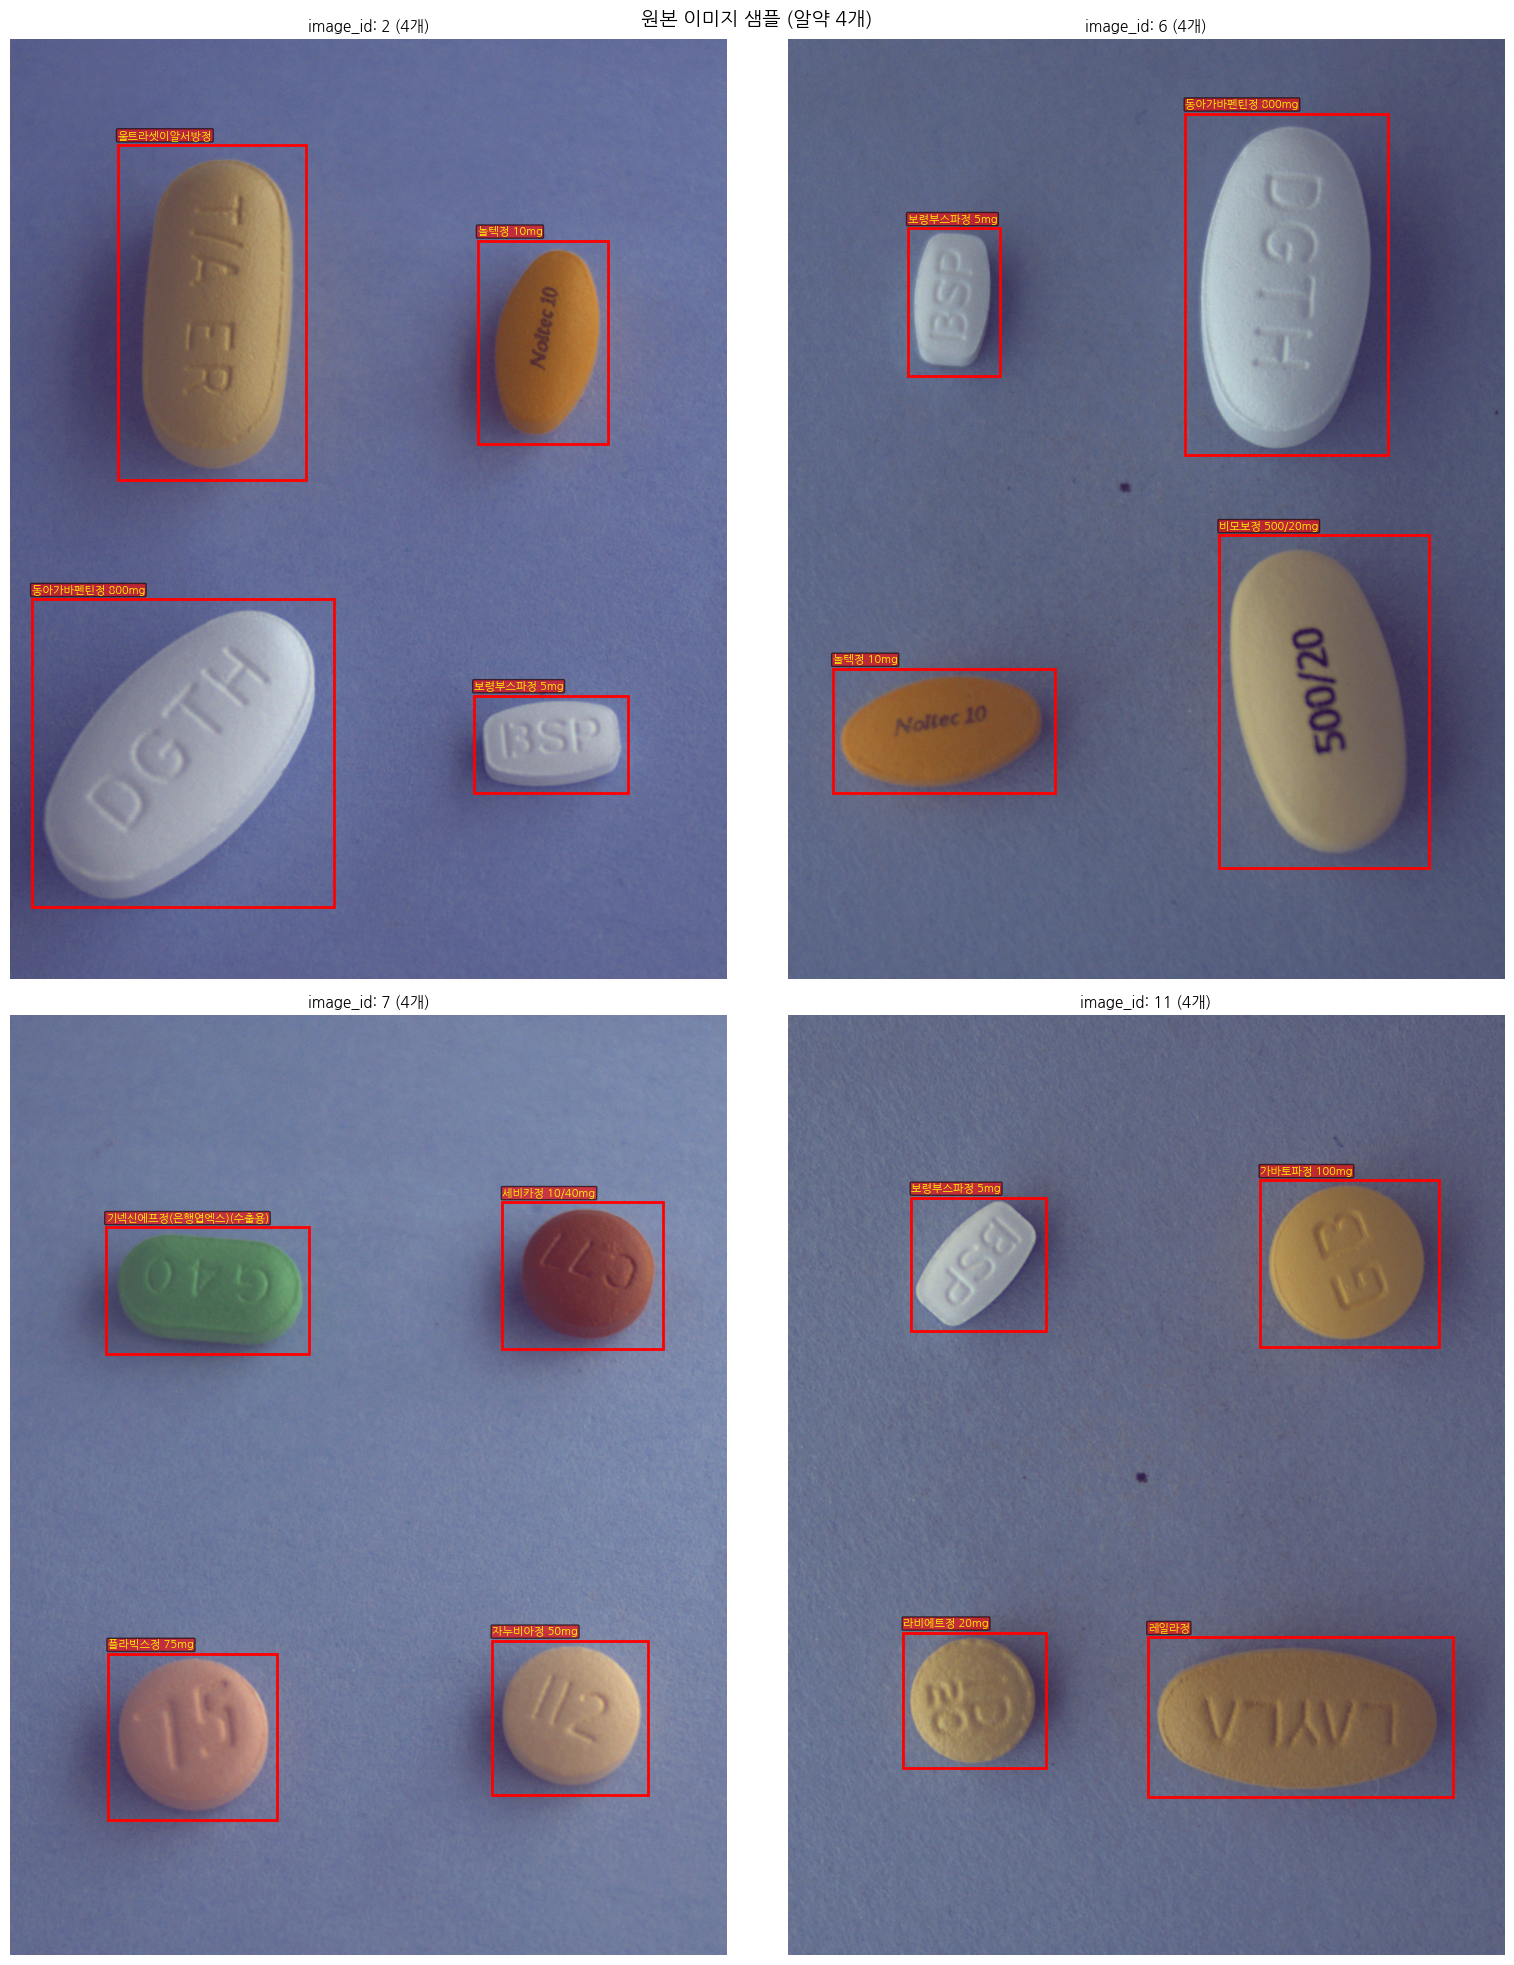

In [29]:
# ── 원본 이미지 샘플 시각화 ───────────────────────────────
img_id2anns = {}
for ann in train_json['annotations']:
    img_id2anns.setdefault(ann['image_id'], []).append(ann)

# 알약 4개짜리 이미지 샘플
sample_ids = [img_id for img_id, cnt in ann_per_image.items() if cnt == 4][:4]

fig, axes = plt.subplots(2, 2, figsize=(16, 20))
axes = axes.flatten()

for ax, img_id in zip(axes, sample_ids):
    img_info = img_id2info[img_id]
    img_path = os.path.join(TRAIN_IMG_DIR, img_info['file_name'])
    img = Image.open(img_path).convert('RGB')
    ax.imshow(img)
    for ann in img_id2anns.get(img_id, []):
        x, y, w, h = ann['bbox']
        rect = patches.Rectangle((x, y), w, h,
                                  linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 8, id2name[ann['category_id']],
                fontsize=8, color='yellow',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='red', alpha=0.6))
    ax.set_title(f"image_id: {img_id} ({len(img_id2anns.get(img_id, []))}개)", fontsize=11)
    ax.axis('off')

plt.suptitle('원본 이미지 샘플 (알약 4개)', fontsize=14)
plt.tight_layout()
plt.show()

In [30]:
# ── file_name ↔ 실제 파일 매칭 검증 ──────────────────────
actual_files = {entry.name for entry in os.scandir(TRAIN_IMG_DIR) if entry.is_file()}

missing = []
for img in train_json['images']:
    if img['file_name'] not in actual_files:
        missing.append(img['file_name'])

print(f"JSON 등록 이미지 수  : {len(train_json['images']):,}장")
print(f"실제 파일 수         : {len(actual_files):,}장")
print(f"매칭 실패 (누락 파일): {len(missing)}장")

if missing:
    print("\n누락 파일 목록:")
    for f in missing:
        print(f"  {f}")
else:
    print("모든 파일 정상 매칭")

JSON 등록 이미지 수  : 1,489장
실제 파일 수         : 1,489장
매칭 실패 (누락 파일): 0장
모든 파일 정상 매칭


In [31]:
# ── Test JSON annotation 존재 여부 확인 ──────────────────
test_anns = test_json.get('annotations', [])
print(f"Test annotation 수: {len(test_anns)}개")

if len(test_anns) > 0:
    print("\n샘플 annotation (앞 3개):")
    for ann in test_anns[:3]:
        print(f"  {ann}")

    # category_id 분포 확인
    test_cat_counter = Counter(ann['category_id'] for ann in test_anns)
    print(f"\n등장 클래스 수 : {len(test_cat_counter)}개")
    print(f"annotation 수  : min={min(test_cat_counter.values())} / "
          f"max={max(test_cat_counter.values())} / "
          f"mean={np.mean(list(test_cat_counter.values())):.1f}")

    # image_id당 annotation 수 확인
    test_ann_per_image = Counter(ann['image_id'] for ann in test_anns)
    print(f"\nimage당 annotation 수: "
          f"min={min(test_ann_per_image.values())} / "
          f"max={max(test_ann_per_image.values())} / "
          f"mean={np.mean(list(test_ann_per_image.values())):.1f}")
else:
    print("annotation 없음 (정상 테스트 데이터)")

Test annotation 수: 1129개

샘플 annotation (앞 3개):
  {'area': 128642, 'iscrowd': 0, 'bbox': [571, 628, 262, 491], 'category_id': 27925, 'ignore': 0, 'segmentation': [], 'id': 4, 'image_id': 3}
  {'area': 123970, 'iscrowd': 0, 'bbox': [600, 671, 253, 490], 'category_id': 27925, 'ignore': 0, 'segmentation': [], 'id': 5, 'image_id': 1}
  {'area': 52380, 'iscrowd': 0, 'bbox': [173, 740, 180, 291], 'category_id': 24849, 'ignore': 0, 'segmentation': [], 'id': 10, 'image_id': 1}

등장 클래스 수 : 73개
annotation 수  : min=1 / max=110 / mean=15.5

image당 annotation 수: min=1 / max=4 / mean=1.3


## 4. 전처리

| 단계 | 내용 |
|------|------|
| 2-1 | 비정상 BBox 제거 |
| 2-2 | category_id 재매핑 (불연속 → 0\~72) |
| 2-3 | letterbox 리사이즈 (976×1280 → 640×640) |
| 2-4 | stratified train/val split (80:20) |
| 2-5 | processed_train.json 저장 |

### 4-1. 비정상 BBox 제거

In [32]:
# ── 1. 비정상 BBox 제거 ───────────────────────────────────
img_id2info = {img['id']: img for img in train_json['images']}

clean_annotations = []
removed = []

for ann in train_json['annotations']:
    img = img_id2info[ann['image_id']]
    x, y, w, h = ann['bbox']
    iw, ih = img['width'], img['height']

    reasons = []
    if x < 0 or y < 0:
        reasons.append(f"음수 좌표 (x={x}, y={y})")
    if w <= 0 or h <= 0:
        reasons.append(f"비정상 크기 (w={w}, h={h})")
    if x + w > iw:
        reasons.append(f"x 범위 초과 (x+w={x+w} > {iw})")
    if y + h > ih:
        reasons.append(f"y 범위 초과 (y+h={y+h} > {ih})")

    if reasons:
        removed.append({
            'ann_id'  : ann['id'],
            'image_id': ann['image_id'],
            'bbox'    : ann['bbox'],
            'reason'  : ' / '.join(reasons)
        })
    else:
        clean_annotations.append(ann)

# ── 결과 출력 ─────────────────────────────────────────────
print(f"제거 전 annotation 수 : {len(train_json['annotations']):,}개")
print(f"제거된 annotation 수  : {len(removed)}개")
print(f"제거 후 annotation 수 : {len(clean_annotations):,}개")

if removed:
    print("\n제거된 항목:")
    for item in removed:
        print(f"  ann_id={item['ann_id']} / image_id={item['image_id']} "
              f"/ bbox={item['bbox']} / 사유={item['reason']}")

제거 전 annotation 수 : 4,526개
제거된 annotation 수  : 2개
제거 후 annotation 수 : 4,524개

제거된 항목:
  ann_id=903 / image_id=239 / bbox=[6567, 625, 311, 315] / 사유=x 범위 초과 (x+w=6878 > 976)
  ann_id=1157 / image_id=310 / bbox=[653, 8889, 217, 217] / 사유=y 범위 초과 (y+h=9106 > 1280)


### 4-2. category_id 재맵핑

In [33]:
# ── 2. category_id 재매핑 ─────────────────────────────────
# 원본 category_id를 정렬 후 0~72 연속 정수로 매핑
sorted_cats = sorted(train_json['categories'], key=lambda c: c['id'])
for cat in sorted_cats:
    cat['name'] = cat['name'].strip()

old_id2new  = {cat['id']: new_id for new_id, cat in enumerate(sorted_cats)}
new_id2old  = {new_id: cat['id'] for new_id, cat in enumerate(sorted_cats)}
new_id2name = {new_id: cat['name'] for new_id, cat in enumerate(sorted_cats)}

# ── 매핑 결과 샘플 출력 ───────────────────────────────────
print("매핑 샘플 (앞 5개):")
for new_id in range(5):
    print(f"  {new_id:2d} <- old_id={new_id2old[new_id]:6d} | {new_id2name[new_id]}")

# ── annotations에 새 category_id 적용 ────────────────────
remapped_annotations = []
for ann in clean_annotations:
    new_ann = ann.copy()
    new_ann['category_id'] = old_id2new[ann['category_id']]
    remapped_annotations.append(new_ann)

# ── categories 목록도 갱신 ────────────────────────────────
remapped_categories = [
    {'id': new_id, 'name': new_id2name[new_id], 'supercategory': 'pill'}
    for new_id in range(len(sorted_cats))
]

# ── 검증 ─────────────────────────────────────────────────
new_cat_ids = sorted(set(ann['category_id'] for ann in remapped_annotations))
print(f"\n재매핑 후 category_id 범위 : {min(new_cat_ids)} ~ {max(new_cat_ids)}")
print(f"고유 category_id 수        : {len(new_cat_ids)}개")
print(f"연속성                     : {'연속' if new_cat_ids == list(range(len(new_cat_ids))) else '[경고] 불연속'}")
print(f"annotation 수              : {len(remapped_annotations):,}개")

매핑 샘플 (앞 5개):
   0 <- old_id=  1899 | 보령부스파정 5mg
   1 <- old_id=  2482 | 뮤테란캡슐 100mg
   2 <- old_id=  3350 | 일양하이트린정 2mg
   3 <- old_id=  3482 | 기넥신에프정(은행엽엑스)(수출용)
   4 <- old_id=  3543 | 무코스타정(레바미피드)(비매품)

재매핑 후 category_id 범위 : 0 ~ 72
고유 category_id 수        : 73개
연속성                     : 연속
annotation 수              : 4,524개


### 4-3. letterbox 리사이즈
976x1280 -> 640x640

- 이미지를 비율을 유지한 상태로 크기를 조절함
- 빈 공간은 padding으로 채움

In [34]:
# ── 3. Letterbox 리사이즈 + BBox 좌표 변환 ───────────────
TARGET_SIZE = 640
PAD_COLOR   = (114, 114, 114)

def letterbox_resize(img, target_size):
    """원본 비율 유지하며 target_size x target_size로 리사이즈 + 패딩"""
    ow, oh = img.size  # 원본 width, height
    scale  = target_size / max(ow, oh)
    nw, nh = int(ow * scale), int(oh * scale)

    # 비율 유지 리사이즈
    img_resized = img.resize((nw, nh), Image.BILINEAR)

    # 패딩 계산 (좌우 or 상하 균등 분배)
    pad_w = (target_size - nw) // 2
    pad_h = (target_size - nh) // 2

    # 새 캔버스에 붙이기
    canvas = Image.new('RGB', (target_size, target_size), PAD_COLOR)
    canvas.paste(img_resized, (pad_w, pad_h))

    return canvas, scale, pad_w, pad_h

def transform_bbox(bbox, scale, pad_w, pad_h):
    """BBox 좌표를 letterbox 변환에 맞게 조정"""
    x, y, w, h = bbox
    new_x = x * scale + pad_w
    new_y = y * scale + pad_h
    new_w = w * scale
    new_h = h * scale
    return [round(new_x, 2), round(new_y, 2), round(new_w, 2), round(new_h, 2)]

# ── 이미지 변환 및 저장 ───────────────────────────────────
img_id2transform = {}  # image_id → (scale, pad_w, pad_h) 저장

total = len(train_json['images'])
for i, img_info in enumerate(train_json['images']):
    img_path = os.path.join(TRAIN_IMG_DIR, img_info['file_name'])
    img      = Image.open(img_path).convert('RGB')

    resized, scale, pad_w, pad_h = letterbox_resize(img, TARGET_SIZE)

    save_path = os.path.join(PROCESSED_IMG_DIR, img_info['file_name'])
    resized.save(save_path)

    img_id2transform[img_info['id']] = (scale, pad_w, pad_h)

    if (i + 1) % 100 == 0 or (i + 1) == total:
        print(f"  저장 완료: {i+1:,} / {total:,}장")

print(f"\n전체 이미지 저장 완료: {PROCESSED_IMG_DIR}")

# ── BBox 좌표 변환 ────────────────────────────────────────
processed_annotations = []
for ann in remapped_annotations:
    scale, pad_w, pad_h = img_id2transform[ann['image_id']]
    new_ann          = ann.copy()
    new_ann['bbox']  = transform_bbox(ann['bbox'], scale, pad_w, pad_h)
    new_ann['area']  = new_ann['bbox'][2] * new_ann['bbox'][3]
    processed_annotations.append(new_ann)

# ── 변환 검증 (샘플 1건) ──────────────────────────────────
sample_ann = remapped_annotations[0]
scale, pad_w, pad_h = img_id2transform[sample_ann['image_id']]
print(f"\n변환 파라미터: scale={scale:.4f}, pad_w={pad_w}, pad_h={pad_h}")
print(f"변환 전 BBox : {sample_ann['bbox']}")
print(f"변환 후 BBox : {processed_annotations[0]['bbox']}")
print(f"\n처리된 annotation 수: {len(processed_annotations):,}개")

  저장 완료: 100 / 1,489장
  저장 완료: 200 / 1,489장
  저장 완료: 300 / 1,489장
  저장 완료: 400 / 1,489장
  저장 완료: 500 / 1,489장
  저장 완료: 600 / 1,489장
  저장 완료: 700 / 1,489장
  저장 완료: 800 / 1,489장
  저장 완료: 900 / 1,489장
  저장 완료: 1,000 / 1,489장
  저장 완료: 1,100 / 1,489장
  저장 완료: 1,200 / 1,489장
  저장 완료: 1,300 / 1,489장
  저장 완료: 1,400 / 1,489장
  저장 완료: 1,489 / 1,489장

전체 이미지 저장 완료: /content/drive/MyDrive/data/초급_프로젝트/dataset/processed_images

변환 파라미터: scale=0.5000, pad_w=76, pad_h=0
변환 전 BBox : [158, 251, 202, 127]
변환 후 BBox : [155.0, 125.5, 101.0, 63.5]

처리된 annotation 수: 4,524개


### 4-4. train/val 

In [35]:
import random


# ── 4. Train / Val Stratified Split ──────────────────────
random.seed(42)

# image_id별 대표 category_id 추출 (이미지당 가장 많이 등장하는 클래스)
img_id2cats = {}
for ann in processed_annotations:
    img_id2cats.setdefault(ann['image_id'], []).append(ann['category_id'])

img_id2rep_cat = {
    img_id: Counter(cats).most_common(1)[0][0]
    for img_id, cats in img_id2cats.items()
}

# 클래스별 image_id 그룹화
cat2img_ids = {}
for img_id, cat in img_id2rep_cat.items():
    cat2img_ids.setdefault(cat, []).append(img_id)

# Stratified Split
train_ids, val_ids = [], []

for cat, img_ids in cat2img_ids.items():
    random.shuffle(img_ids)
    if len(img_ids) == 1:
        train_ids.extend(img_ids)
    else:
        n_val = max(1, int(len(img_ids) * 0.2))
        val_ids.extend(img_ids[:n_val])
        train_ids.extend(img_ids[n_val:])

train_ids = set(train_ids)
val_ids   = set(val_ids)

# ── Val 누락 클래스 보정 ──────────────────────────────────
# annotation 기준으로 각 클래스가 속한 image_id 전체 파악
cat2all_img_ids = {}
for ann in processed_annotations:
    cat2all_img_ids.setdefault(ann['category_id'], set()).add(ann['image_id'])

train_cat_counts = Counter(ann['category_id'] for ann in processed_annotations if ann['image_id'] in train_ids)
val_cat_counts   = Counter(ann['category_id'] for ann in processed_annotations if ann['image_id'] in val_ids)
missing_in_val   = set(train_cat_counts.keys()) - set(val_cat_counts.keys())

for cat_id in missing_in_val:
    # 해당 클래스가 포함된 이미지 중 Train에 있는 것 1장을 Val로 이동
    candidates = [img_id for img_id in cat2all_img_ids[cat_id] if img_id in train_ids]
    if candidates:
        move_id = candidates[0]
        train_ids.remove(move_id)
        val_ids.add(move_id)
        print(f"  보정: image_id={move_id} → Val로 이동 (클래스: {new_id2name[cat_id]})")

# ── 결과 출력 ─────────────────────────────────────────────
print(f"\nTrain 이미지 수 : {len(train_ids):,}장")
print(f"Val   이미지 수 : {len(val_ids):,}장")
print(f"합계            : {len(train_ids) + len(val_ids):,}장")

# ── 중복/누락 검증 ────────────────────────────────────────
all_img_ids = {img['id'] for img in train_json['images']}
overlap     = train_ids & val_ids
missing     = all_img_ids - (train_ids | val_ids)

print(f"\nTrain-Val 중복 : {len(overlap)}장")
print(f"누락 이미지    : {len(missing)}장")

# ── annotation 분리 ───────────────────────────────────────
train_annotations = [ann for ann in processed_annotations if ann['image_id'] in train_ids]
val_annotations   = [ann for ann in processed_annotations if ann['image_id'] in val_ids]

print(f"\nTrain annotation 수 : {len(train_annotations):,}개")
print(f"Val   annotation 수 : {len(val_annotations):,}개")

# ── 클래스 비율 유지 검증 ─────────────────────────────────
train_cat_counts = Counter(ann['category_id'] for ann in train_annotations)
val_cat_counts   = Counter(ann['category_id'] for ann in val_annotations)

print(f"\n클래스 수 - Train: {len(train_cat_counts)}개 / Val: {len(val_cat_counts)}개")

# Val 누락 클래스 최종 확인
missing_final = set(train_cat_counts.keys()) - set(val_cat_counts.keys())
if missing_final:
    print(f"[경고] Val 누락 클래스: {len(missing_final)}개")
    for cat_id in missing_final:
        print(f"  new_id={cat_id} / {new_id2name[cat_id]}")
else:
    print("모든 클래스 Train/Val 모두 포함")

  보정: image_id=808 → Val로 이동 (클래스: 렉사프로정 15mg)

Train 이미지 수 : 1,214장
Val   이미지 수 : 275장
합계            : 1,489장

Train-Val 중복 : 0장
누락 이미지    : 0장

Train annotation 수 : 3,684개
Val   annotation 수 : 840개

클래스 수 - Train: 73개 / Val: 73개
모든 클래스 Train/Val 모두 포함


### 4-5. 전처리된 JSON 저장 ###

In [36]:
# ── 5. 전처리된 JSON 저장 ─────────────────────────────────

# images width/height를 640×640으로 갱신
processed_images = []
for img in train_json['images']:
    new_img = img.copy()
    new_img['width']  = TARGET_SIZE
    new_img['height'] = TARGET_SIZE
    processed_images.append(new_img)

# 저장할 JSON 구성
processed_json = {
    'images'     : processed_images,
    'annotations': processed_annotations,
    'categories' : remapped_categories,
    'train_ids'  : list(train_ids),
    'val_ids'    : list(val_ids),
    'mappings'   : {
        'old_id2new' : {str(k): v for k, v in old_id2new.items()},
        'new_id2old' : {str(k): v for k, v in new_id2old.items()},
        'new_id2name': {str(k): v for k, v in new_id2name.items()},
    }
}

# 저장
with open(PROCESSED_JSON_PATH, 'w', encoding='utf-8') as f:
    json.dump(processed_json, f, ensure_ascii=False, indent=2)

print(f"저장 완료: {PROCESSED_JSON_PATH}")

# ── 저장 결과 검증 ────────────────────────────────────────
with open(PROCESSED_JSON_PATH, 'r', encoding='utf-8') as f:
    verify = json.load(f)

print(f"\n[검증]")
print(f"  images      : {len(verify['images']):,}장")
print(f"  annotations : {len(verify['annotations']):,}개")
print(f"  categories  : {len(verify['categories'])}개")
print(f"  train_ids   : {len(verify['train_ids']):,}장")
print(f"  val_ids     : {len(verify['val_ids']):,}장")

# category_id 범위 최종 확인
cat_ids = [ann['category_id'] for ann in verify['annotations']]
print(f"\ncategory_id 범위 : {min(cat_ids)} ~ {max(cat_ids)}")
print(f"이미지 width     : {verify['images'][0]['width']}")
print(f"이미지 height    : {verify['images'][0]['height']}")

# mappings 샘플 확인
print(f"\n매핑 샘플 (앞 3개):")
for new_id in range(3):
    old_id = verify['mappings']['new_id2old'][str(new_id)]
    name   = verify['mappings']['new_id2name'][str(new_id)]
    print(f"  new_id={new_id} / old_id={old_id} / {name}")

저장 완료: /content/drive/MyDrive/data/초급_프로젝트/dataset/processed_train.json

[검증]
  images      : 1,489장
  annotations : 4,524개
  categories  : 73개
  train_ids   : 1,214장
  val_ids     : 275장

category_id 범위 : 0 ~ 72
이미지 width     : 640
이미지 height    : 640

매핑 샘플 (앞 3개):
  new_id=0 / old_id=1899 / 보령부스파정 5mg
  new_id=1 / old_id=2482 / 뮤테란캡슐 100mg
  new_id=2 / old_id=3350 / 일양하이트린정 2mg


### 4-6. 전처리 결과 검증 ###

1. 저장된 이미지 파일 수 및 크기 검증
저장된 이미지 수 : 2,285장 (기대값: 1,489장)
크기 오류 (640×640 아닌 파일) : 0장
모든 이미지 640×640 확인

2. BBox 좌표 범위 검증 (0 ~ 640)
비정상 BBox 수 : 0개
모든 BBox 정상 범위 확인

3. Train/Val 클래스 분포 비율 검증
new_id   클래스명                               전체  Train   Val    Val비율
----------------------------------------------------------------------
  0      보령부스파정 5mg                        180    142    38   21.1%
  1      뮤테란캡슐 100mg                       172    143    29   16.9%
  2      일양하이트린정 2mg                       240    197    43   17.9%
  3      기넥신에프정(은행엽엑스)(수출용)                514    418    96   18.7%
  4      무코스타정(레바미피드)(비매품)                  98     83    15   15.3%
  5      알드린정                               54     48     6   11.1%
  6      뉴로메드정(옥시라세탐)                       27     20     7   25.9%
  7      타이레놀정500mg                         33     29     4   12.1%
  8      에어탈정(아세클로페낙)                       29     24     5   17.2%
  9      삼남건조수산화알루미늄겔정                      56     42    1

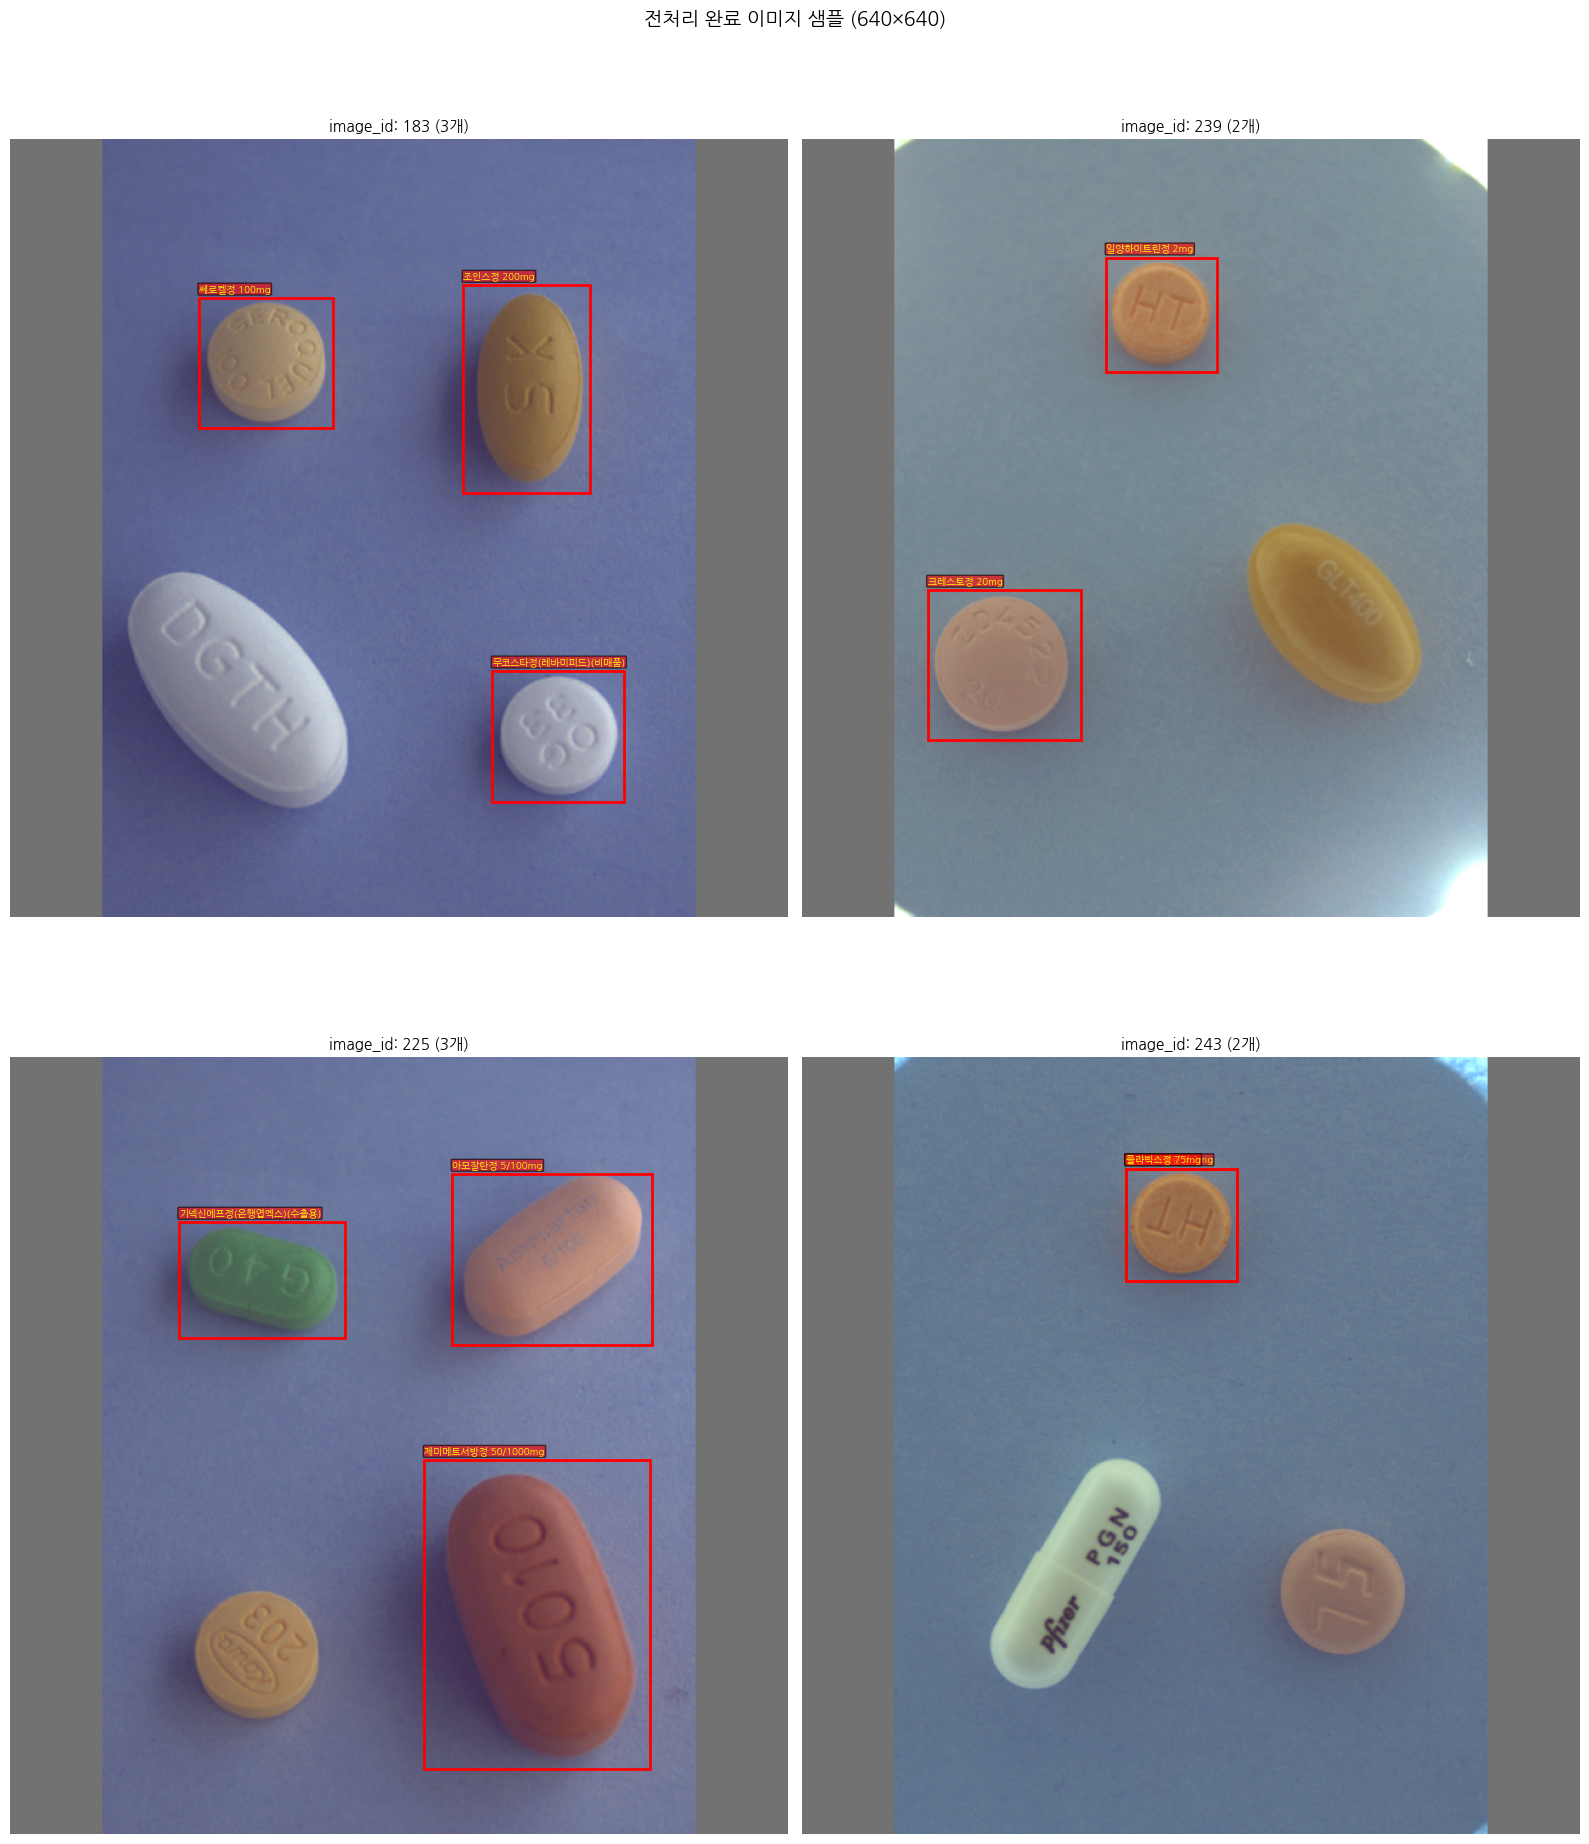

In [37]:
# ── 전처리 최종 검증 ──────────────────────────────────────
print("=" * 50)
print("1. 저장된 이미지 파일 수 및 크기 검증")
print("=" * 50)

processed_files = list(os.scandir(PROCESSED_IMG_DIR))
processed_files = [f for f in processed_files if f.name.lower().endswith(IMG_EXTENSIONS)]

print(f"저장된 이미지 수 : {len(processed_files):,}장 (기대값: {len(processed_images):,}장)")

size_errors = []
for entry in processed_files[:]:
    img = Image.open(entry.path)
    if img.size != (TARGET_SIZE, TARGET_SIZE):
        size_errors.append({'file': entry.name, 'size': img.size})

print(f"크기 오류 (640×640 아닌 파일) : {len(size_errors)}장")
if size_errors:
    for e in size_errors:
        print(f"  {e['file']} : {e['size']}")
else:
    print("모든 이미지 640×640 확인")

# ── 2. BBox 좌표 범위 검증 ────────────────────────────────
print("\n" + "=" * 50)
print("2. BBox 좌표 범위 검증 (0 ~ 640)")
print("=" * 50)

bbox_errors = []
for ann in processed_annotations:
    x, y, w, h = ann['bbox']
    reasons = []
    if x < 0 or y < 0:
        reasons.append(f"음수 좌표 (x={x:.1f}, y={y:.1f})")
    if w <= 0 or h <= 0:
        reasons.append(f"비정상 크기 (w={w:.1f}, h={h:.1f})")
    if x + w > TARGET_SIZE:
        reasons.append(f"x 범위 초과 (x+w={x+w:.1f} > {TARGET_SIZE})")
    if y + h > TARGET_SIZE:
        reasons.append(f"y 범위 초과 (y+h={y+h:.1f} > {TARGET_SIZE})")
    if reasons:
        bbox_errors.append({
            'ann_id'  : ann['id'],
            'image_id': ann['image_id'],
            'bbox'    : ann['bbox'],
            'reason'  : ' / '.join(reasons)
        })

print(f"비정상 BBox 수 : {len(bbox_errors)}개")
if bbox_errors:
    for e in bbox_errors:
        print(f"  ann_id={e['ann_id']} / image_id={e['image_id']} "
              f"/ bbox={e['bbox']} / 사유={e['reason']}")
else:
    print("모든 BBox 정상 범위 확인")

# ── 3. 클래스 분포 비율 검증 ──────────────────────────────
print("\n" + "=" * 50)
print("3. Train/Val 클래스 분포 비율 검증")
print("=" * 50)

total_cat_counts = Counter(ann['category_id'] for ann in processed_annotations)
train_cat_counts = Counter(ann['category_id'] for ann in train_annotations)
val_cat_counts   = Counter(ann['category_id'] for ann in val_annotations)

print(f"{'new_id':<8} {'클래스명':<30} {'전체':>6} {'Train':>6} {'Val':>5} {'Val비율':>8}")
print("-" * 70)
ratio_errors = []
for cat_id in range(len(remapped_categories)):
    total = total_cat_counts.get(cat_id, 0)
    train = train_cat_counts.get(cat_id, 0)
    val   = val_cat_counts.get(cat_id, 0)
    val_ratio = val / total if total > 0 else 0
    # 기대 Val 비율 0.2 기준 ±0.15 이상 벗어나면 경고
    flag = " [경고]" if abs(val_ratio - 0.2) > 0.15 and total >= 5 else ""
    print(f"  {cat_id:<6} {new_id2name[cat_id]:<30} {total:>6} {train:>6} {val:>5} {val_ratio:>7.1%}{flag}")
    if flag:
        ratio_errors.append(cat_id)

print(f"\n비율 이상 클래스 수 : {len(ratio_errors)}개")
print(f"Train 클래스 수     : {len(train_cat_counts)}개")
print(f"Val   클래스 수     : {len(val_cat_counts)}개")

# ── 4. 샘플 이미지 + 변환된 BBox 시각화 ──────────────────
print("\n" + "=" * 50)
print("4. 샘플 이미지 + 변환 BBox 시각화")
print("=" * 50)

proc_img_id2anns = {}
for ann in processed_annotations:
    proc_img_id2anns.setdefault(ann['image_id'], []).append(ann)

proc_img_id2info = {img['id']: img for img in processed_images}

sample_ids = random.sample(list(train_ids), 4)

fig, axes = plt.subplots(2, 2, figsize=(16, 20))
axes = axes.flatten()

for ax, img_id in zip(axes, sample_ids):
    img_info = proc_img_id2info[img_id]
    img_path = os.path.join(PROCESSED_IMG_DIR, img_info['file_name'])
    img      = Image.open(img_path).convert('RGB')
    ax.imshow(img)
    for ann in proc_img_id2anns.get(img_id, []):
        x, y, w, h = ann['bbox']
        rect = patches.Rectangle((x, y), w, h,
                                  linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 5, new_id2name[ann['category_id']],
                fontsize=7, color='yellow',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='red', alpha=0.6))
    ax.set_title(f"image_id: {img_id} ({len(proc_img_id2anns.get(img_id, []))}개)", fontsize=11)
    ax.axis('off')

plt.suptitle('전처리 완료 이미지 샘플 (640×640)', fontsize=14)
plt.tight_layout()
plt.show()

## 5. DataLoader 구성 ##

***모델 : YOLOv8m***

현재 가장 널리 쓰이는 1-stage detector입니다. 속도와 정확도 균형이 뛰어나고, Ultralytics 라이브러리로 학습/추론 코드가 매우 간결합니다.

- 장점: 빠른 학습 속도, 코드 간결, 데이터 증강 내장, mAP 성능 우수
- 단점: YOLO 포맷으로 데이터 변환 필요
- 권장 batch_size: 8~16
- 권장 모델 크기: yolov8m (medium) - 속도/정확도 균형

-----
#### 모델 ####
- 모델: YOLOv8m
- 사전학습 가중치: yolov8m.pt (COCO)

#### 데이터 ####
- 이미지 크기: 640×640
- 클래스 수: 73
- Train: 1,214장 / Val: 275장
- 포맷: YOLO (x_center, y_center, w, h 정규화)

#### 학습 하이퍼파라미터 ####
- epochs: 50
- batch_size: 10
- optimizer: AdamW
- learning_rate: 0.001
- image_size: 640

#### 데이터 증강 (YOLOv8 내장) ####
- Mosaic: 활성화
- MixUp: 활성화
- HSV 색상 변환: 활성화
- RandomHorizontalFlip: 활성화

#### 학습 설정 ####
- Early stopping: patience=20
- 체크포인트 저장: Google Drive

#### 미결정 사항 (추후 진행) ####
- 클래스 불균형 해소 전략 (Focal Loss / 클래스 가중치)
- confidence threshold
- IoU threshold (NMS)
- Kaggle 제출 포맷 변환 (YOLO 출력 → COCO 포맷)


### 5-1. 이미지 포멧 변환 ###

COCO(기존 이미지 형식) [x, y, w, h] → YOLO [x_center, y_center, w, h]

심볼릭 링크(Symbolic Link)를 사용하여 실제 파일을 복사하지 않고, 원본 파일의 경로를 가리키는 포인터를 만들어 사용한다.

심볼릭 링크는 실제 파일 없이 원본을 참조하므로 용량 추가 없이 YOLO가 요구하는 디렉토리 구조를 만들 수 있습니다.

In [38]:
# ── YOLO 포맷 변환 ────────────────────────────────────────
YOLO_DIR         = normalize_path(os.path.join(extract_path, "yolo_dataset"))
YOLO_LABEL_TRAIN = os.path.join(YOLO_DIR, "labels", "train")
YOLO_LABEL_VAL   = os.path.join(YOLO_DIR, "labels", "val")
YOLO_IMG_TRAIN   = os.path.join(YOLO_DIR, "images", "train")
YOLO_IMG_VAL     = os.path.join(YOLO_DIR, "images", "val")
YOLO_YAML_PATH   = os.path.join(YOLO_DIR, "data.yaml")

os.makedirs(YOLO_LABEL_TRAIN, exist_ok=True)
os.makedirs(YOLO_LABEL_VAL,   exist_ok=True)
os.makedirs(YOLO_IMG_TRAIN,   exist_ok=True)
os.makedirs(YOLO_IMG_VAL,     exist_ok=True)

# aug_images가 정의되지 않은 경우 빈 리스트로 초기화
if 'aug_images' not in dir():
    aug_images = []
    print("[경고] aug_images 미정의 → 증강 이미지 없이 진행")

# ── BBox 변환 함수 (COCO → YOLO 정규화) ──────────────────
def coco_to_yolo(bbox, img_w, img_h):
    """[x, y, w, h] → [x_center, y_center, w, h] (0~1 정규화)"""
    x, y, w, h = bbox
    x_center = (x + w / 2) / img_w
    y_center = (y + h / 2) / img_h
    w_norm   = w / img_w
    h_norm   = h / img_h
    x_center = min(max(x_center, 0.0), 1.0)
    y_center = min(max(y_center, 0.0), 1.0)
    w_norm   = min(max(w_norm,   0.0), 1.0)
    h_norm   = min(max(h_norm,   0.0), 1.0)
    return x_center, y_center, w_norm, h_norm

# ── image_id별 annotation 그룹화 ─────────────────────────
yolo_img_id2anns = {}
for ann in processed_annotations:
    yolo_img_id2anns.setdefault(ann['image_id'], []).append(ann)

# ── 라벨 .txt 생성 + 이미지 복사 ─────────────────────────
def write_yolo_labels_and_copy(img_ids, label_dir, img_dir,
                                extra_img_list=None):
    count = 0
    for img_info in processed_images:
        if img_info['id'] not in img_ids:
            continue

        img_w = img_info['width']
        img_h = img_info['height']

        # 라벨 .txt 작성
        label_path = os.path.join(label_dir,
                     os.path.splitext(img_info['file_name'])[0] + '.txt')
        anns = yolo_img_id2anns.get(img_info['id'], [])
        with open(label_path, 'w') as f:
            for ann in anns:
                cat_id = ann['category_id']
                x_c, y_c, w_n, h_n = coco_to_yolo(ann['bbox'], img_w, img_h)
                f.write(f"{cat_id} {x_c:.6f} {y_c:.6f} {w_n:.6f} {h_n:.6f}\n")

        # 이미지 복사
        src = os.path.join(PROCESSED_IMG_DIR, img_info['file_name'])
        dst = os.path.join(img_dir, img_info['file_name'])
        shutil.copy2(src, dst)
        count += 1

    # 증강 이미지 복사 (Train만)
    if extra_img_list:
        for img_info in extra_img_list:
            src = os.path.join(PROCESSED_IMG_DIR, img_info['file_name'])
            dst = os.path.join(img_dir, img_info['file_name'])
            if os.path.exists(src):
                shutil.copy2(src, dst)

                # 증강 라벨 존재 여부 확인
                label_name = os.path.splitext(img_info['file_name'])[0] + '.txt'
                if not os.path.exists(os.path.join(YOLO_LABEL_TRAIN, label_name)):
                    print(f"[경고] 라벨 없음: {label_name}")

                count += 1

    return count

n_train = write_yolo_labels_and_copy(train_ids, YOLO_LABEL_TRAIN,
                                      YOLO_IMG_TRAIN, aug_images)
n_val   = write_yolo_labels_and_copy(val_ids,   YOLO_LABEL_VAL,
                                      YOLO_IMG_VAL)

print(f"Train 이미지/라벨 생성 : {n_train:,}개")
print(f"Val   이미지/라벨 생성 : {n_val:,}개")

# ── data.yaml 생성 (디렉토리 방식) ───────────────────────
yaml_content = f"""train: {YOLO_IMG_TRAIN}
val: {YOLO_IMG_VAL}

nc: {len(remapped_categories)}
names: {[new_id2name[i] for i in range(len(remapped_categories))]}
"""

with open(YOLO_YAML_PATH, 'w', encoding='utf-8') as f:
    f.write(yaml_content)

print(f"\ndata.yaml 저장 : {YOLO_YAML_PATH}")

# ── 검증 ─────────────────────────────────────────────────
n_train_imgs   = len(os.listdir(YOLO_IMG_TRAIN))
n_val_imgs     = len(os.listdir(YOLO_IMG_VAL))
n_train_labels = len(os.listdir(YOLO_LABEL_TRAIN))
n_val_labels   = len(os.listdir(YOLO_LABEL_VAL))

print(f"\n[검증]")
print(f"Train 이미지 수 : {n_train_imgs:,}  /  라벨 수 : {n_train_labels:,}")
print(f"Val   이미지 수 : {n_val_imgs:,}  /  라벨 수 : {n_val_labels:,}")

if n_train_imgs != n_train_labels:
    print(f"[경고] Train 이미지 / 라벨 수 불일치")
if n_val_imgs != n_val_labels:
    print(f"[경고] Val 이미지 / 라벨 수 불일치")

# 샘플 라벨 출력
sample_label      = os.listdir(YOLO_LABEL_TRAIN)[0]
sample_label_path = os.path.join(YOLO_LABEL_TRAIN, sample_label)
print(f"\n샘플 라벨 ({sample_label}):")
with open(sample_label_path, 'r') as f:
    print(f.read())

print("data.yaml 내용:")
with open(YOLO_YAML_PATH, 'r', encoding='utf-8') as f:
    print(f.read())

[경고] aug_images 미정의 → 증강 이미지 없이 진행
Train 이미지/라벨 생성 : 1,214개
Val   이미지/라벨 생성 : 275개

data.yaml 저장 : /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_dataset/data.yaml

[검증]
Train 이미지 수 : 1,214  /  라벨 수 : 2,010
Val   이미지 수 : 275  /  라벨 수 : 275
[경고] Train 이미지 / 라벨 수 불일치

샘플 라벨 (K-003483-020877-029667-030308_0_2_0_2_70_000_200.txt):
56 0.313281 0.759375 0.181250 0.178125
58 0.692578 0.758203 0.321094 0.328906
34 0.709375 0.298438 0.251563 0.190625
3 0.314453 0.325781 0.164844 0.200000

data.yaml 내용:
train: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_dataset/images/train
val: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_dataset/images/val

nc: 73
names: ['보령부스파정 5mg', '뮤테란캡슐 100mg', '일양하이트린정 2mg', '기넥신에프정(은행엽엑스)(수출용)', '무코스타정(레바미피드)(비매품)', '알드린정', '뉴로메드정(옥시라세탐)', '타이레놀정500mg', '에어탈정(아세클로페낙)', '삼남건조수산화알루미늄겔정', '타이레놀이알서방정(아세트아미노펜)(수출용)', '삐콤씨에프정 618.6mg/병', '조인스정 200mg', '쎄로켈정 100mg', '리렉스펜정 300mg/PTP', '아빌리파이정 10mg', '자이프렉사정 2.5mg', '다보타민큐정 10mg/병', '써스펜8시간이알서방정 650mg', '에빅사정(메만틴염산염

### 5-2. 클래스 불균형 해소 ###


#### 클래스 불균형 해소 - 오버샘플링 ####

###### 왜 하는가? #####
현재 Train 데이터의 클래스별 샘플 수가 최대 418개 ~ 최소 6개로 불균형 상태입니다.

이 상태로 학습하면 다음 문제가 발생합니다.
- 모델이 샘플이 많은 클래스에 편향되어 학습됨
- 희귀 클래스는 학습 기회 자체가 부족해 탐지 성능이 낮아짐
- 전체 mAP는 낮아지고, 특히 희귀 클래스의 AP가 0에 가까워짐

##### 무엇을 하는가? #####
Train 세트에서 평균(62개) 미만인 클래스를 대상으로
부족한 샘플 수만큼 기존 이미지를 복사 + 증강하여 새로운 이미지를 생성합니다.

##### 증강 방법 #####
| 항목 | 설정 | 이유 |
|---|---|---|
| ColorJitter | brightness=0.2, contrast=0.2 | 촬영 환경 차이 시뮬레이션, 약하게 적용해 색상 특징 유지 |
| RandomRotation | ±20도 | 알약 놓인 방향 다양화, Flip 대신 선택해 문자 보존 |

##### 처리 흐름 #####

평균(62개) 미만 클래스 탐지
→ 해당 클래스 포함 Train 이미지 선별
→ 부족한 수만큼 랜덤 선택 + 증강 적용
→ 증강 이미지 processed_images/ 저장
→ YOLO 라벨 .txt 동일하게 생성
→ train_images.txt 업데이트

##### 주의사항 #####
- Val 세트에는 적용하지 않습니다. (실제 데이터 분포 유지 필요)
- 증강 강도를 약하게 설정해 원본 특징(색상, 형태)을 최대한 보존합니다.
- 오버샘플링은 Train 세트에만 적용되므로 평가 신뢰도에 영향을 주지 않습니다.

In [39]:
# ── 클래스 불균형 해소 - 오버샘플링 ──────────────────────
from PIL import ImageEnhance

OVERSAMPLE_TARGET = int(df_class['count'].mean())  # 62
ROTATION_RANGE    = 20
BRIGHTNESS_FACTOR = 0.2
CONTRAST_FACTOR   = 0.2

print(f"오버샘플링 목표 샘플 수 : {OVERSAMPLE_TARGET}개")

# ── Train annotation 기준 클래스별 샘플 수 집계 ───────────
train_cat_counts = Counter(ann['category_id'] for ann in processed_annotations
                           if ann['image_id'] in train_ids)

# 평균 미만 클래스 탐지
undersampled_cats = {cat_id: cnt for cat_id, cnt in train_cat_counts.items()
                     if cnt < OVERSAMPLE_TARGET}

print(f"오버샘플링 대상 클래스 수 : {len(undersampled_cats)}개")

# ── 클래스별 Train 이미지 목록 구성 ──────────────────────
cat2train_imgs = {}
for ann in processed_annotations:
    if ann['image_id'] in train_ids:
        cat2train_imgs.setdefault(ann['category_id'], set()).add(ann['image_id'])

# ── 증강 함수 ─────────────────────────────────────────────
def augment_image(img):
    """ColorJitter (밝기/대비) + RandomRotation 약하게 적용"""
    # 밝기 조정
    brightness = 1.0 + random.uniform(-BRIGHTNESS_FACTOR, BRIGHTNESS_FACTOR)
    img = ImageEnhance.Brightness(img).enhance(brightness)
    # 대비 조정
    contrast = 1.0 + random.uniform(-CONTRAST_FACTOR, CONTRAST_FACTOR)
    img = ImageEnhance.Contrast(img).enhance(contrast)
    # 회전
    angle = random.uniform(-ROTATION_RANGE, ROTATION_RANGE)
    img = img.rotate(angle, resample=Image.BILINEAR, expand=False,
                     fillcolor=(114, 114, 114))
    return img, angle

def rotate_bbox(bbox, angle, img_w, img_h):
    """BBox를 회전 각도에 맞게 변환 (중심 기준 회전)"""
    import math
    x, y, w, h = bbox
    cx, cy = img_w / 2, img_h / 2

    # BBox 4꼭짓점
    corners = [
        (x,     y),
        (x + w, y),
        (x + w, y + h),
        (x,     y + h),
    ]

    rad = math.radians(-angle)
    rotated = []
    for px, py in corners:
        rx = cx + (px - cx) * math.cos(rad) - (py - cy) * math.sin(rad)
        ry = cy + (px - cx) * math.sin(rad) + (py - cy) * math.cos(rad)
        rotated.append((rx, ry))

    xs = [p[0] for p in rotated]
    ys = [p[1] for p in rotated]
    new_x = max(min(xs), 0)
    new_y = max(min(ys), 0)
    new_w = min(max(xs), img_w) - new_x
    new_h = min(max(ys), img_h) - new_y

    return [round(new_x, 2), round(new_y, 2),
            round(new_w, 2), round(new_h, 2)]

# ── 오버샘플링 실행 ───────────────────────────────────────
new_img_paths   = []
aug_img_id_base = max(img['id'] for img in processed_images) + 1
aug_ann_id_base = max(ann['id'] for ann in processed_annotations) + 1
aug_img_id      = aug_img_id_base
aug_ann_id      = aug_ann_id_base

aug_images      = []
aug_annotations = []

for cat_id, cur_cnt in undersampled_cats.items():
    needed     = OVERSAMPLE_TARGET - cur_cnt
    candidate_imgs = list(cat2train_imgs.get(cat_id, []))

    if not candidate_imgs:
        continue

    for i in range(needed):
        src_img_id   = random.choice(candidate_imgs)
        src_img_info = proc_img_id2info[src_img_id]
        src_img_path = os.path.join(PROCESSED_IMG_DIR, src_img_info['file_name'])

        img = Image.open(src_img_path).convert('RGB')
        aug_img, angle = augment_image(img)

        # 저장 파일명
        aug_filename = f"aug_{aug_img_id}_{src_img_info['file_name']}"
        aug_save_path = os.path.join(PROCESSED_IMG_DIR, aug_filename)
        aug_img.save(aug_save_path)

        # 이미지 메타데이터 추가
        aug_img_info = src_img_info.copy()
        aug_img_info['id']        = aug_img_id
        aug_img_info['file_name'] = aug_filename
        aug_images.append(aug_img_info)

        # annotation 변환
        src_anns = proc_img_id2anns.get(src_img_id, [])
        for ann in src_anns:
            new_ann              = ann.copy()
            new_ann['id']        = aug_ann_id
            new_ann['image_id']  = aug_img_id
            new_ann['bbox']      = rotate_bbox(ann['bbox'], angle,
                                               src_img_info['width'],
                                               src_img_info['height'])
            new_ann['area']      = new_ann['bbox'][2] * new_ann['bbox'][3]
            aug_annotations.append(new_ann)
            aug_ann_id += 1

        # YOLO 라벨 .txt 생성
        label_filename = os.path.splitext(aug_filename)[0] + '.txt'
        label_path     = os.path.join(YOLO_LABEL_TRAIN, label_filename)
        with open(label_path, 'w') as f:
            for ann in aug_annotations[-len(src_anns):]:
                x_c, y_c, w_n, h_n = coco_to_yolo(ann['bbox'],
                                                    src_img_info['width'],
                                                    src_img_info['height'])
                f.write(f"{ann['category_id']} {x_c:.6f} {y_c:.6f} "
                        f"{w_n:.6f} {h_n:.6f}\n")

        new_img_paths.append(aug_save_path)
        aug_img_id += 1

print(f"\n생성된 증강 이미지 수 : {len(aug_images):,}장")
print(f"생성된 증강 annotation 수 : {len(aug_annotations):,}개")

# # ── train_images.txt 업데이트 ─────────────────────────────
# with open(TRAIN_IMG_TXT, 'a') as f:
#     f.write('\n' + '\n'.join(new_img_paths))

# print(f"train_images.txt 업데이트 완료")

# ── 오버샘플링 전후 클래스 분포 비교 ─────────────────────
aug_cat_counts = Counter(ann['category_id'] for ann in aug_annotations)
after_counts   = {cat_id: train_cat_counts.get(cat_id, 0) + aug_cat_counts.get(cat_id, 0)
                  for cat_id in range(len(remapped_categories))}

print(f"\n{'new_id':<8} {'클래스명':<30} {'증강 전':>8} {'증강 후':>8}")
print("-" * 60)
for cat_id in sorted(undersampled_cats.keys()):
    before = train_cat_counts.get(cat_id, 0)
    after  = after_counts.get(cat_id, 0)
    print(f"  {cat_id:<6} {new_id2name[cat_id]:<30} {before:>8} {after:>8}")

print(f"\n증강 후 Train 이미지 총 수 : {len(train_ids) + len(aug_images):,}장")
print(f"증강 후 Train annotation 총 수 : "
      f"{len(train_annotations) + len(aug_annotations):,}개")

오버샘플링 목표 샘플 수 : 62개
오버샘플링 대상 클래스 수 : 50개

생성된 증강 이미지 수 : 1,849장
생성된 증강 annotation 수 : 5,744개

new_id   클래스명                               증강 전     증강 후
------------------------------------------------------------
  5      알드린정                                 48      146
  6      뉴로메드정(옥시라세탐)                         20       82
  7      타이레놀정500mg                           29       94
  8      에어탈정(아세클로페낙)                         24      181
  9      삼남건조수산화알루미늄겔정                        42      128
  10     타이레놀이알서방정(아세트아미노펜)(수출용)              28       97
  11     삐콤씨에프정 618.6mg/병                     27      103
  12     조인스정 200mg                           30      184
  13     쎄로켈정 100mg                           29       83
  14     리렉스펜정 300mg/PTP                      26       93
  15     아빌리파이정 10mg                          14       75
  16     자이프렉사정 2.5mg                          8       77
  17     다보타민큐정 10mg/병                        32      100
  18     써스펜8시간이알서방정 650mg       

##### 재설정 #####

***평균값인 62로 맞추려고 했으니, 해당 약이 포함된 이미지에 다른 약들의 수가 늘어나는 문제가 발생***

-> 목표 개수를 40으로 정정해서 다시 증강

In [40]:
# ── 이전 증강 결과 초기화 ─────────────────────────────────

# processed_images/ 내 증강 이미지 삭제
removed_imgs = 0
for entry in os.scandir(PROCESSED_IMG_DIR):
    if entry.name.startswith('aug_'):
        os.remove(entry.path)
        removed_imgs += 1

# YOLO_IMG_TRAIN 내 증강 이미지 삭제
removed_train_imgs = 0
for entry in os.scandir(YOLO_IMG_TRAIN):
    if entry.name.startswith('aug_'):
        os.remove(entry.path)
        removed_train_imgs += 1

# YOLO_LABEL_TRAIN 내 증강 라벨 삭제
removed_labels = 0
for entry in os.scandir(YOLO_LABEL_TRAIN):
    if entry.name.startswith('aug_'):
        os.remove(entry.path)
        removed_labels += 1

print(f"삭제된 증강 이미지 수 (processed) : {removed_imgs:,}장")
print(f"삭제된 증강 이미지 수 (yolo/train): {removed_train_imgs:,}장")
print(f"삭제된 증강 라벨 수               : {removed_labels:,}개")

삭제된 증강 이미지 수 (processed) : 2,641장
삭제된 증강 이미지 수 (yolo/train): 0장
삭제된 증강 라벨 수               : 2,641개


In [41]:
# ── 클래스 불균형 해소 - 오버샘플링 (목표: 40개) ──────────
OVERSAMPLE_TARGET = 40
ROTATION_RANGE    = 20
BRIGHTNESS_FACTOR = 0.2
CONTRAST_FACTOR   = 0.2

print(f"오버샘플링 목표 샘플 수 : {OVERSAMPLE_TARGET}개")

# ── Train annotation 기준 클래스별 샘플 수 집계 ───────────
train_cat_counts = Counter(ann['category_id'] for ann in processed_annotations
                           if ann['image_id'] in train_ids)

undersampled_cats = {cat_id: cnt for cat_id, cnt in train_cat_counts.items()
                     if cnt < OVERSAMPLE_TARGET}

print(f"오버샘플링 대상 클래스 수 : {len(undersampled_cats)}개")

# ── 클래스별 Train 이미지 목록 구성 ──────────────────────
cat2train_imgs = {}
for ann in processed_annotations:
    if ann['image_id'] in train_ids:
        cat2train_imgs.setdefault(ann['category_id'], set()).add(ann['image_id'])

# ── 오버샘플링 실행 ───────────────────────────────────────
aug_img_id_base = max(img['id'] for img in processed_images) + 1
aug_ann_id_base = max(ann['id'] for ann in processed_annotations) + 1
aug_img_id      = aug_img_id_base
aug_ann_id      = aug_ann_id_base

aug_images      = []
aug_annotations = []

for cat_id, cur_cnt in undersampled_cats.items():
    needed         = OVERSAMPLE_TARGET - cur_cnt
    candidate_imgs = list(cat2train_imgs.get(cat_id, []))

    if not candidate_imgs:
        continue

    for i in range(needed):
        src_img_id   = random.choice(candidate_imgs)
        src_img_info = proc_img_id2info[src_img_id]
        src_img_path = os.path.join(PROCESSED_IMG_DIR, src_img_info['file_name'])

        img = Image.open(src_img_path).convert('RGB')
        aug_img, angle = augment_image(img)

        aug_filename  = f"aug_{aug_img_id}_{src_img_info['file_name']}"
        aug_save_path = os.path.join(PROCESSED_IMG_DIR, aug_filename)
        aug_img.save(aug_save_path)

        aug_img_info              = src_img_info.copy()
        aug_img_info['id']        = aug_img_id
        aug_img_info['file_name'] = aug_filename
        aug_images.append(aug_img_info)

        src_anns = proc_img_id2anns.get(src_img_id, [])
        for ann in src_anns:
            new_ann             = ann.copy()
            new_ann['id']       = aug_ann_id
            new_ann['image_id'] = aug_img_id
            new_ann['bbox']     = rotate_bbox(ann['bbox'], angle,
                                              src_img_info['width'],
                                              src_img_info['height'])
            new_ann['area']     = new_ann['bbox'][2] * new_ann['bbox'][3]
            aug_annotations.append(new_ann)
            aug_ann_id += 1

        # YOLO 라벨 .txt 생성 (YOLO_LABEL_TRAIN에 저장)
        label_filename = os.path.splitext(aug_filename)[0] + '.txt'
        label_path     = os.path.join(YOLO_LABEL_TRAIN, label_filename)
        with open(label_path, 'w') as f:
            for ann in aug_annotations[-len(src_anns):]:
                x_c, y_c, w_n, h_n = coco_to_yolo(ann['bbox'],
                                                    src_img_info['width'],
                                                    src_img_info['height'])
                f.write(f"{ann['category_id']} {x_c:.6f} {y_c:.6f} "
                        f"{w_n:.6f} {h_n:.6f}\n")

        aug_img_id += 1

print(f"\n생성된 증강 이미지 수     : {len(aug_images):,}장")
print(f"생성된 증강 annotation 수 : {len(aug_annotations):,}개")

# ── 오버샘플링 전후 클래스 분포 비교 ─────────────────────
aug_cat_counts = Counter(ann['category_id'] for ann in aug_annotations)
after_counts   = {cat_id: train_cat_counts.get(cat_id, 0) + aug_cat_counts.get(cat_id, 0)
                  for cat_id in range(len(remapped_categories))}

print(f"\n{'new_id':<8} {'클래스명':<30} {'증강 전':>8} {'증강 후':>8}")
print("-" * 60)
for cat_id in sorted(undersampled_cats.keys()):
    before = train_cat_counts.get(cat_id, 0)
    after  = after_counts.get(cat_id, 0)
    print(f"  {cat_id:<6} {new_id2name[cat_id]:<30} {before:>8} {after:>8}")

print(f"\n증강 후 Train 이미지 총 수     : {len(train_ids) + len(aug_images):,}장")
print(f"증강 후 Train annotation 총 수 : "
      f"{len(train_annotations) + len(aug_annotations):,}개")

오버샘플링 목표 샘플 수 : 40개
오버샘플링 대상 클래스 수 : 45개

생성된 증강 이미지 수     : 796장
생성된 증강 annotation 수 : 2,491개

new_id   클래스명                               증강 전     증강 후
------------------------------------------------------------
  6      뉴로메드정(옥시라세탐)                         20       49
  7      타이레놀정500mg                           29       46
  8      에어탈정(아세클로페낙)                         24      104
  10     타이레놀이알서방정(아세트아미노펜)(수출용)              28       47
  11     삐콤씨에프정 618.6mg/병                     27       45
  12     조인스정 200mg                           30      114
  13     쎄로켈정 100mg                           29       52
  14     리렉스펜정 300mg/PTP                      26       45
  15     아빌리파이정 10mg                          14       47
  16     자이프렉사정 2.5mg                          8       41
  17     다보타민큐정 10mg/병                        32       51
  18     써스펜8시간이알서방정 650mg                    27       53
  19     에빅사정(메만틴염산염)(비매품)                    21       48
  24     오마코연질캡슐(오메가-3-산에틸에스테르9

여전히 다른 약들의 수가 목표를 초ㅗ가하는 일이 발생

- 클래스 8  (에어탈정): 24 → 110  (목표 초과 70개)
- 클래스 12 (조인스정): 30 → 110  (목표 초과 70개)

하지만 수가 오차범위 이내라고 판단하고, 그대로 진행하겠습니다.

### 5-3. yolov8m 모델 학습 ###

##### 모델 설정 #####
| 옵션 | 값 | 설명 |
|---|---|---|
| model | yolov8m.pt | COCO 사전학습 가중치 |
| task | detect | 객체 탐지 |

##### 학습 하이퍼파라미터 #####
| 옵션 | 값 | 설명 |
|---|---|---|
| epochs | 50 | 전체 학습 반복 수 |
| batch | 10 | 배치 크기 |
| optimizer | AdamW | 옵티마이저 |
| lr0 | 0.001 | 초기 학습률 |
| lrf | 0.01 | 최종 학습률 비율 (lr0 * lrf가 최종값) |
| weight_decay | 0.0005 | 과적합 방지 |
| warmup_epochs | 3 | 초반 학습률 워밍업 구간 |

##### 증강 설정 #####
| 옵션 | 값 | 설명 |
|---|---|---|
| mosaic | 1.0 | Mosaic 증강 활성화 |
| mixup | 0.1 | MixUp 증강 약하게 적용 |
| hsv_h | 0.015 | 색상(Hue) 변환 범위 |
| hsv_s | 0.7 | 채도(Saturation) 변환 범위 |
| hsv_v | 0.4 | 명도(Value) 변환 범위 |
| degrees | 10.0 | 회전 범위 (±10도) |
| fliplr | 0.0 | 좌우 반전 비활성화 (문자 있는 알약 고려) |
| flipud | 0.0 | 상하 반전 비활성화 |

##### 학습 관리 #####
| 옵션 | 값 | 설명 |
|---|---|---|
| patience | 20 | Early stopping 기준 epoch 수 |
| save | True | 체크포인트 저장 |
| project | Google Drive 경로 | 결과 저장 위치 |
| name | yolov8m_oral_drug | 실험 이름 |
| exist_ok | True | 동일 실험명 덮어쓰기 허용 |
| device | 0 | GPU 사용 |
| workers | 2 | 데이터 로딩 worker 수 |

In [ ]:
# ── 기본 로그 출력 억제 ───────────────────────────────────
LOGGER.setLevel(logging.WARNING)

# ── 경로 설정 ─────────────────────────────────────────────
YOLO_PROJECT_DIR = normalize_path(os.path.join(extract_path, "yolo_runs"))
EXPERIMENT_NAME  = "yolov8m_oral_drug"

os.makedirs(YOLO_PROJECT_DIR, exist_ok=True)

# ── 콜백 함수 정의 ────────────────────────────────────────
def on_train_epoch_end(trainer):
    epoch    = trainer.epoch + 1
    epochs   = trainer.epochs
    box_loss = trainer.loss_items[0].item() if trainer.loss_items is not None else 0
    cls_loss = trainer.loss_items[1].item() if trainer.loss_items is not None else 0
    dfl_loss = trainer.loss_items[2].item() if trainer.loss_items is not None else 0
    print(f"[Epoch {epoch:3d}/{epochs}]  "
          f"box_loss: {box_loss:.4f}  "
          f"cls_loss: {cls_loss:.4f}  "
          f"dfl_loss: {dfl_loss:.4f}")

def on_val_end(validator):
    metrics = validator.metrics
    map50    = metrics.box.map50   if hasattr(metrics, 'box') else 0
    map5095  = metrics.box.map     if hasattr(metrics, 'box') else 0
    print(f"           └─ Val  mAP50: {map50:.4f}  mAP50-95: {map5095:.4f}")

def on_train_end(trainer):
    print(f"\n{'='*55}")
    print(f"학습 완료")
    print(f"  저장 경로     : {trainer.save_dir}")
    print(f"{'='*55}")

# ── 모델 로드 및 콜백 등록 ────────────────────────────────
model = YOLO("yolov8m.pt")
model.add_callback("on_train_epoch_end", on_train_epoch_end)
model.add_callback("on_val_end",         on_val_end)
model.add_callback("on_train_end",       on_train_end)

# ── 학습 실행 ─────────────────────────────────────────────
results = model.train(
    # 데이터
    data    = YOLO_YAML_PATH,
    imgsz   = 640,

    # 학습 하이퍼파라미터
    epochs       = 50,
    batch        = 10,
    optimizer    = "AdamW",
    lr0          = 0.001,
    lrf          = 0.01,
    weight_decay = 0.0005,
    warmup_epochs= 3,

    # 증강
    mosaic  = 1.0,
    mixup   = 0.1,
    hsv_h   = 0.015,
    hsv_s   = 0.7,
    hsv_v   = 0.4,
    degrees = 10.0,
    fliplr  = 0.0,
    flipud  = 0.0,

    # 학습 관리
    patience  = 20,
    save      = True,
    project   = YOLO_PROJECT_DIR,
    name      = EXPERIMENT_NAME,
    exist_ok  = True,
    device    = 0,
    workers   = 2,
    verbose   = False,
)

## 6. 결과 분석 ##

In [45]:
# ── Inference 전용 복원 셀 (세션 재시작 후 실행) ──────────
import os, json
import unicodedata

def normalize_path(path):
    return unicodedata.normalize('NFC', path).strip()

# ── 경로 설정 ─────────────────────────────────────────────
extract_path     = normalize_path("/content/drive/MyDrive/data/초급_프로젝트/dataset/")
PROCESSED_JSON_PATH = normalize_path(os.path.join(extract_path, "processed_train.json"))
TEST_IMG_DIR        = normalize_path(os.path.join(extract_path, "test_images"))
SUBMISSION_PATH     = normalize_path(os.path.join(extract_path, "submission.csv"))
YOLO_PROJECT_DIR    = normalize_path(os.path.join(extract_path, "yolo_runs"))
EXPERIMENT_NAME     = "yolov8m_oral_drug"
BEST_MODEL_PATH     = os.path.join(YOLO_PROJECT_DIR, EXPERIMENT_NAME, "weights", "best.pt")

# ── 전처리 JSON에서 매핑 복원 ─────────────────────────────
with open(PROCESSED_JSON_PATH, 'r', encoding='utf-8') as f:
    processed_json = json.load(f)

new_id2old  = {int(k): v for k, v in processed_json['mappings']['new_id2old'].items()}
new_id2name = {int(k): v for k, v in processed_json['mappings']['new_id2name'].items()}
old_id2new  = {int(k): v for k, v in processed_json['mappings']['old_id2new'].items()}

# ── 상수 설정 ─────────────────────────────────────────────
TARGET_SIZE    = 640
ORIG_W, ORIG_H = 976, 1280
SCALE = TARGET_SIZE / max(ORIG_W, ORIG_H)
PAD_W = (TARGET_SIZE - int(ORIG_W * SCALE)) // 2
PAD_H = (TARGET_SIZE - int(ORIG_H * SCALE)) // 2
IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp')

# ── BBox 역변환 함수 ──────────────────────────────────────
def yolo_to_original(x_c, y_c, w_n, h_n, target_size, scale, pad_w, pad_h):
    x_center = x_c * target_size - pad_w
    y_center = y_c * target_size - pad_h
    w_px     = w_n * target_size
    h_px     = h_n * target_size
    x_center /= scale
    y_center /= scale
    w_orig   = w_px / scale
    h_orig   = h_px / scale
    x = max(0, min(x_center - w_orig / 2, ORIG_W))
    y = max(0, min(y_center - h_orig / 2, ORIG_H))
    w_orig = min(w_orig, ORIG_W - x)
    h_orig = min(h_orig, ORIG_H - y)
    return round(x), round(y), round(w_orig), round(h_orig)

# ── 복원 결과 확인 ────────────────────────────────────────
print(f"매핑 복원 완료 : {len(new_id2old)}개 클래스")
print(f"역변환 파라미터: scale={SCALE}, pad_w={PAD_W}, pad_h={PAD_H}")
print(f"모델 존재 여부 : {'OK' if os.path.exists(BEST_MODEL_PATH) else '[경고] 모델 파일 없음'}")
print(f"Test 이미지 수 : {sum(1 for f in os.scandir(TEST_IMG_DIR) if f.name.lower().endswith(IMG_EXTENSIONS)):,}장")

매핑 복원 완료 : 73개 클래스
역변환 파라미터: scale=0.5, pad_w=76, pad_h=0
모델 존재 여부 : OK
Test 이미지 수 : 843장


In [46]:
# ── Inference 설정 ────────────────────────────────────────
BEST_MODEL_PATH = os.path.join(YOLO_PROJECT_DIR, EXPERIMENT_NAME, "weights", "best.pt")
SUBMISSION_PATH = normalize_path(os.path.join(extract_path, "submission.csv"))

BEST_MODEL_PATH = os.path.join(YOLO_PROJECT_DIR, EXPERIMENT_NAME, "weights", "best.pt")
SUBMISSION_PATH = normalize_path(os.path.join(extract_path, "submission.csv"))

# 원본 이미지 크기
ORIG_W, ORIG_H = 976, 1280

# Letterbox 역변환 파라미터 (전처리와 동일)
SCALE = TARGET_SIZE / max(ORIG_W, ORIG_H)  # 0.5
PAD_W = (TARGET_SIZE - int(ORIG_W * SCALE)) // 2  # 76
PAD_H = (TARGET_SIZE - int(ORIG_H * SCALE)) // 2  # 0

print(f"모델 경로       : {BEST_MODEL_PATH}")
print(f"역변환 파라미터 : scale={SCALE}, pad_w={PAD_W}, pad_h={PAD_H}")
print(f"모델 존재 여부  : {'OK' if os.path.exists(BEST_MODEL_PATH) else '[경고] 모델 파일 없음'}")

# ── BBox 역변환 함수 (640×640 → 976×1280) ────────────────
def yolo_to_original(x_c, y_c, w_n, h_n, target_size, scale, pad_w, pad_h):
    """YOLO 정규화 좌표 → 원본 이미지 COCO BBox [x, y, w, h]"""
    # 정규화 해제 (640 기준 픽셀 좌표)
    x_center = x_c * target_size
    y_center = y_c * target_size
    w_px     = w_n * target_size
    h_px     = h_n * target_size

    # 패딩 제거
    x_center -= pad_w
    y_center -= pad_h

    # 스케일 역변환
    x_center /= scale
    y_center /= scale
    w_orig    = w_px / scale
    h_orig    = h_px / scale

    # COCO 형식 [x, y, w, h]
    x = x_center - w_orig / 2
    y = y_center - h_orig / 2

    # 원본 이미지 범위 클리핑
    x      = max(0, min(x, ORIG_W))
    y      = max(0, min(y, ORIG_H))
    w_orig = min(w_orig, ORIG_W - x)
    h_orig = min(h_orig, ORIG_H - y)

    return round(x), round(y), round(w_orig), round(h_orig)

모델 경로       : /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_runs/yolov8m_oral_drug/weights/best.pt
역변환 파라미터 : scale=0.5, pad_w=76, pad_h=0
모델 존재 여부  : OK


In [47]:
# ── Inference 실행 및 제출 CSV 생성 ──────────────────────
from ultralytics import YOLO

model = YOLO(BEST_MODEL_PATH)

# Test 이미지 목록 (숫자 순 정렬)
test_img_files = sorted([
    f for f in os.listdir(TEST_IMG_DIR)
    if f.lower().endswith(IMG_EXTENSIONS)
], key=lambda x: int(os.path.splitext(x)[0]))

print(f"Test 이미지 수 : {len(test_img_files):,}장")

rows          = []
annotation_id = 1

for fname in test_img_files:
    img_path = os.path.join(TEST_IMG_DIR, fname)
    image_id = int(os.path.splitext(fname)[0])  # 파일명에서 image_id 직접 추출

    # Inference
    result = model.predict(
        source  = img_path,
        imgsz   = 640,
        conf    = 0.25,
        iou     = 0.5,
        verbose = False,
    )[0]

    boxes       = result.boxes
    num_objects = len(boxes)

    if num_objects == 0:
        rows.append({
            'annotation_id': annotation_id,
            'image_id'     : image_id,
            'num_objects'  : 0,
            'category_id'  : -1,
            'bbox_x'       : 0,
            'bbox_y'       : 0,
            'bbox_w'       : 0,
            'bbox_h'       : 0,
        })
        annotation_id += 1
        continue

    for box in boxes:
        x_c, y_c, w_n, h_n = box.xywhn[0].tolist()
        new_cat_id = int(box.cls[0].item())

        # BBox 역변환 (640 → 976×1280)
        bx, by, bw, bh = yolo_to_original(
            x_c, y_c, w_n, h_n,
            TARGET_SIZE, SCALE, PAD_W, PAD_H
        )

        # category_id 역변환 (new_id → old_id)
        old_cat_id = new_id2old[new_cat_id]

        rows.append({
            'annotation_id': annotation_id,
            'image_id'     : image_id,
            'num_objects'  : num_objects,
            'category_id'  : old_cat_id,
            'bbox_x'       : bx,
            'bbox_y'       : by,
            'bbox_w'       : bw,
            'bbox_h'       : bh,
        })
        annotation_id += 1

# ── CSV 저장 ──────────────────────────────────────────────
df_submission = pd.DataFrame(rows, columns=[
    'annotation_id', 'image_id', 'num_objects',
    'category_id', 'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h'
])

df_submission.to_csv(SUBMISSION_PATH, index=False)

print(f"\n제출 파일 저장 완료 : {SUBMISSION_PATH}")
print(f"총 행 수            : {len(df_submission):,}")
print(f"탐지된 이미지 수    : {df_submission['image_id'].nunique():,} / {len(test_img_files):,}")
print(f"이미지당 평균 탐지  : {len(df_submission) / len(test_img_files):.2f}개")

# ── 샘플 출력 ─────────────────────────────────────────────
print(f"\n제출 샘플 (앞 5행):")
print(df_submission.head().to_string(index=False))

# ── 포맷 검증 ─────────────────────────────────────────────
print(f"\n[검증]")
print(f"category_id 범위 : {df_submission['category_id'].min()} ~ {df_submission['category_id'].max()}")
print(f"bbox_x 범위      : {df_submission['bbox_x'].min()} ~ {df_submission['bbox_x'].max()} (기대: 0~{ORIG_W})")
print(f"bbox_y 범위      : {df_submission['bbox_y'].min()} ~ {df_submission['bbox_y'].max()} (기대: 0~{ORIG_H})")
invalid_bbox = df_submission[
    (df_submission['bbox_x'] < 0) |
    (df_submission['bbox_y'] < 0) |
    (df_submission['bbox_x'] + df_submission['bbox_w'] > ORIG_W) |
    (df_submission['bbox_y'] + df_submission['bbox_h'] > ORIG_H)
]
print(f"범위 초과 BBox   : {len(invalid_bbox)}개")

Test 이미지 수 : 843장

제출 파일 저장 완료 : /content/drive/MyDrive/data/초급_프로젝트/dataset/submission.csv
총 행 수            : 3,235
탐지된 이미지 수    : 843 / 843
이미지당 평균 탐지  : 3.84개

제출 샘플 (앞 5행):
 annotation_id  image_id  num_objects  category_id  bbox_x  bbox_y  bbox_w  bbox_h
             1         1            4         1899      55     251     267     125
             2         1            4        24849      76     741     234     290
             3         1            4        27925     630     673     342     487
             4         1            4        16550     578      65     398     418
             5         3            4         1899      33     240     259     130

[검증]
category_id 범위 : 1899 ~ 44198
bbox_x 범위      : 0 ~ 908 (기대: 0~976)
bbox_y 범위      : 0 ~ 1181 (기대: 0~1280)
범위 초과 BBox   : 0개


In [48]:
# ── Test JSON file_name vs 실제 파일명 비교 ───────────────
print("Test JSON file_name 샘플 (앞 3개):")
for img in test_json['images'][:3]:
    print(f"  id={img['id']} / file_name={img['file_name']}")

print("\n실제 Test 이미지 파일명 샘플 (앞 3개):")
for f in sorted(os.listdir(TEST_IMG_DIR))[:3]:
    print(f"  {f}")

Test JSON file_name 샘플 (앞 3개):
  id=3 / file_name=K-001900-016551-024850-027926_0_2_0_2_75_000_200.png
  id=1 / file_name=K-001900-016551-024850-027926_0_2_0_2_90_000_200.png
  id=5 / file_name=K-001900-016551-024850-029345_0_2_0_2_90_000_200.png

실제 Test 이미지 파일명 샘플 (앞 3개):
  1.png
  10.png
  100.png
